## Setup & Installation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================================
# INSTALL REQUIRED PACKAGES
# ============================================================================

print("Installing all required packages...")

# Core ML & Data Science
!pip install -q numpy pandas matplotlib seaborn
!pip install -q scikit-learn scikit-image
!pip install -q imbalanced-learn

# Deep Learning
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q timm

# Computer Vision
!pip install -q opencv-python-headless
!pip install -q Pillow

# Hugging Face & Datasets
!pip install -q datasets huggingface_hub

# Visualization & Utils
!pip install -q tqdm
!pip install -q grad-cam

print("✓ All packages installed successfully!")

Installing all required packages...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 137.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✓ All packages installed successfully!


In [ ]:
# ============================================================================
# IMPORT REQUIRED LIBRARIES
# ============================================================================

print("Importing libraries...")

# Standard Python Libraries
import os
import sys
import json
import math
import random
import time
import shutil
import psutil
from pathlib import Path
from datetime import datetime
from collections import defaultdict, Counter

# Data Processing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Progress Bars
from tqdm.auto import tqdm

# Computer Vision
import cv2
from PIL import Image, ImageFile

# Deep Learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
import timm

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# Hugging Face Datasets
from datasets import load_dataset

def set_seed(seed=42):
    """Set random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Display configuration
print("="*80)
print("ENVIRONMENT CONFIGURATION")
print("="*80)
print(f"✓ PyTorch Version: {torch.__version__}")
print(f"✓ Torchvision Version: {torchvision.__version__}")
print(f"✓ Device: {device}")
if torch.cuda.is_available():
    print(f"✓ GPU: {torch.cuda.get_device_name(0)}")
    print(f"✓ CUDA Version: {torch.version.cuda}")
    print(f"✓ GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("⚠ No GPU available, using CPU")
print(f"✓ Numpy Version: {np.__version__}")
print(f"✓ Pandas Version: {pd.__version__}")

print("✓ All libraries imported successfully!")

Importing libraries...
ENVIRONMENT CONFIGURATION
✓ PyTorch Version: 2.11.0+cu128
✓ Torchvision Version: 0.26.0+cu128
✓ Device: cuda
✓ GPU: NVIDIA A100-SXM4-40GB
✓ CUDA Version: 12.8
✓ GPU Memory: 42.41 GB
✓ Numpy Version: 2.0.2
✓ Pandas Version: 2.2.2
✓ All libraries imported successfully!


In [ ]:
# ============================================================================
# PROJECT PATHS, CONSTANTS, AND HELPERS
# ============================================================================

PROJECT_DIR = "/content/drive/MyDrive/skripsi"

# Dataset directories
DATASET_DIR = os.path.join(PROJECT_DIR, "dataset_image")
SID_SET_RAW_DIR = "/content/sid_set_raw"
VIDEO_DATASET_DIR = os.path.join(PROJECT_DIR, "dataset_video")

# Output directories
MODEL_DIR = "/content/models"
OUTPUT_DIR = "/content/outputs"
EXPERIMENT_ROOT = os.path.join(PROJECT_DIR, "experiments")
VIS_ROOT = os.path.join(PROJECT_DIR, "visualizations")

# Cleaning reports
CLEAN_ROOT = os.path.join(PROJECT_DIR, "cleaning_reports")
IMAGE_CLEAN_DIR = os.path.join(CLEAN_ROOT, "image")
IMAGE_CLEAN_CSV = os.path.join(IMAGE_CLEAN_DIR, "image_clean_dataset.csv")
IMAGE_SUMMARY_JSON = os.path.join(IMAGE_CLEAN_DIR, "image_cleaning_summary.json")
VIDEO_CLEAN_CSV = os.path.join(CLEAN_ROOT, "video", "video_clean_dataset.csv")

# Shared split manifests.
SPLIT_DIR = os.path.join(PROJECT_DIR, "shared_splits")
IMAGE_SPLIT_CSV = os.path.join(SPLIT_DIR, "image_split.csv")
VIDEO_SPLIT_CSV = os.path.join(SPLIT_DIR, "video_split.csv")
IMAGE_BINARY_INPUT_CSV = os.path.join(SPLIT_DIR, "image_binary_input.csv")
MIXED_INPUT_CSV = os.path.join(SPLIT_DIR, "mixed_input.csv")

# Experiment constants
RANDOM_SEED = 42
TARGET_IMAGE_SAMPLE = 10000
IMG_SIZE = 224
BATCH_SIZE = 32

IMAGE_SELECTION_MODELS = {
    "EfficientNet-B4": "efficientnet_b4",
    "ResNet-50": "resnet50",
    "EfficientNet-B0": "efficientnet_b0",
}

SELECTED_IMAGE_MODEL = None
SELECTED_IMAGE_BACKBONE = None
MODEL_NAME = None

CLASS_NAMES = ["Real", "Full-Synthetic", "Tampered"]
LABEL_NAMES = {
    0: "Real",
    1: "Full-Synthetic",
    2: "Tampered",
}
NUM_CLASSES = len(CLASS_NAMES)

IMAGE_CLASS_LABELS = {
    "real": 0,
    "full_synthetic": 1,
    "tampered": 2,
}
IMAGE_CLASS_FOLDER = {LABEL_NAMES[label]: folder for folder, label in IMAGE_CLASS_LABELS.items()}

BINARY_NAMES = ["Real", "Fake"]

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}
VIDEO_EXTENSIONS = {".mp4", ".avi", ".mov", ".mkv", ".webm"}

for project_path in [
    MODEL_DIR,
    OUTPUT_DIR,
    EXPERIMENT_ROOT,
    VIS_ROOT,
    IMAGE_CLEAN_DIR,
    SPLIT_DIR,
]:
    os.makedirs(project_path, exist_ok=True)

def make_run_dirs(exp_name):
    """Return and create the standard directory structure for one experiment."""
    run_dir = os.path.join(EXPERIMENT_ROOT, exp_name)
    checkpoint_dir = os.path.join(run_dir, "checkpoints")
    report_dir = os.path.join(run_dir, "reports")
    vis_dir = os.path.join(run_dir, "visualizations")

    for path in [run_dir, checkpoint_dir, report_dir, vis_dir]:
        os.makedirs(path, exist_ok=True)

    return run_dir, checkpoint_dir, report_dir, vis_dir

def to_binary_label(label_id):
    """Map image labels from 3-class format to binary format."""
    return 0 if int(label_id) == 0 else 1

def show_label_dist(title, labels, label_names=LABEL_NAMES):
    """Print a compact class distribution summary."""
    counts = Counter([int(label) for label in labels])
    print(f"\n{title}")
    for label_id, label_name in label_names.items():
        count = counts.get(label_id, 0)
        pct = count / max(len(labels), 1) * 100
        print(f"  {label_name:<16}: {count:6,} ({pct:5.2f}%)")

print("Project paths, constants, and helpers are ready.")
print("Image model selection candidates:")
for candidate_name, backbone_name in IMAGE_SELECTION_MODELS.items():
    print(f"  - {candidate_name}: {backbone_name}")

Project paths, constants, and helpers are ready.
Image model selection candidates:
  - EfficientNet-B4: efficientnet_b4
  - ResNet-50: resnet50
  - EfficientNet-B0: efficientnet_b0


## Image Path

3-class classifier: Real / Full-Synthetic / Tampered

### Dataset Preparation


In [ ]:
# ============================================================================
# DATASET
# ============================================================================

ImageFile.LOAD_TRUNCATED_IMAGES = False

print("IMAGE DATASET PREPARATION...")

def count_images(root_dir):
    counts = Counter()
    root = Path(root_dir)

    for folder, label in IMAGE_CLASS_LABELS.items():
        class_dir = root / folder
        if class_dir.exists():
            counts[label] = sum(
                1 for p in class_dir.rglob("*")
                if p.suffix.lower() in IMAGE_EXTENSIONS
            )

    return counts

def ready(root_dir, min_total=1):
    counts = count_images(root_dir)
    total = sum(counts.values())
    has_classes = all(counts.get(label, 0) > 0 for label in LABEL_NAMES)
    return total >= min_total and has_classes


def cache_ok():
    if not os.path.exists(IMAGE_CLEAN_CSV):
        return False

    try:
        df = pd.read_csv(IMAGE_CLEAN_CSV)
    except Exception:
        return False

    cols_ok = {"image_path", "label", "class_name"}.issubset(df.columns)
    paths_ok = len(df) > 0 and df["image_path"].map(os.path.exists).all()
    return cols_ok and paths_ok


def get_label(example):
    keys = ["label", "labels", "class", "class_name", "category", "folder"]

    for key in keys:
        if key not in example:
            continue

        value = example[key]

        if isinstance(value, (int, np.integer)) and int(value) in LABEL_NAMES:
            return int(value)

        text = str(value).lower().replace("-", "_").replace(" ", "_")
        if "real" in text:
            return 0
        if "full" in text and "synthetic" in text:
            return 1
        if "tampered" in text or "manipulated" in text:
            return 2

    path_text = " ".join(str(v).lower() for v in example.values() if isinstance(v, str))
    if "real" in path_text:
        return 0
    if "full_synthetic" in path_text or "full-synthetic" in path_text:
        return 1
    if "tampered" in path_text:
        return 2

    return None

def get_image(example):
    for key in ["image", "img", "file", "jpg", "png"]:
        if key not in example:
            continue

        value = example[key]

        if isinstance(value, Image.Image):
            return value.convert("RGB")

        if isinstance(value, str) and os.path.exists(value):
            return Image.open(value).convert("RGB")

        if isinstance(value, dict) and "path" in value and os.path.exists(value["path"]):
            return Image.open(value["path"]).convert("RGB")

    return None


def download_raw(raw_dir, target_size=10000, seed=42):
    if ready(DATASET_DIR, min_total=target_size) and cache_ok():
        print(f"✓ Clean image dataset already exists: {DATASET_DIR}")
        return

    if os.path.exists(raw_dir):
        shutil.rmtree(raw_dir)
    os.makedirs(raw_dir, exist_ok=True)

    labels = sorted(LABEL_NAMES.keys())
    per_class = target_size // len(labels)
    remainder = target_size % len(labels)

    target_counts = {
        label: per_class + (1 if idx < remainder else 0)
        for idx, label in enumerate(labels)
    }

    for folder in IMAGE_CLASS_LABELS:
        os.makedirs(os.path.join(raw_dir, folder), exist_ok=True)

    print("Downloading SID_Set...")
    ds = load_dataset("saberzl/SID_Set", split="train", streaming=True)
    saved = Counter()

    for example in tqdm(ds, desc="Downloading SID_Set"):
        if all(saved.get(label, 0) >= target_counts[label] for label in labels):
            break

        label = get_label(example)
        if label is None or saved.get(label, 0) >= target_counts[label]:
            continue

        img = get_image(example)
        if img is None:
            continue

        folder = [k for k, v in IMAGE_CLASS_LABELS.items() if v == label][0]
        out_path = os.path.join(raw_dir, folder, f"{saved[label]:06d}.jpg")
        img.save(out_path, quality=95)
        saved[label] += 1

    print("Raw image counts:")
    for label, name in LABEL_NAMES.items():
        print(f"  {name:<16}: {saved.get(label, 0):,}")

def list_image(root_dir):
    records = []
    root = Path(root_dir)

    for folder, label in IMAGE_CLASS_LABELS.items():
        class_dir = root / folder
        if not class_dir.exists():
            continue

        for p in sorted(class_dir.rglob("*")):
            if p.suffix.lower() in IMAGE_EXTENSIONS:
                records.append({
                    "source_path": str(p),
                    "label": int(label),
                    "class_name": LABEL_NAMES[label],
                })

    return pd.DataFrame(records).drop_duplicates(subset=["source_path"]).reset_index(drop=True)

def check_image(path):
    if not os.path.exists(path):
        return False, "missing_file"
    if Path(path).suffix.lower() not in IMAGE_EXTENSIONS:
        return False, "invalid_extension"
    if os.path.getsize(path) == 0:
        return False, "empty_file"

    try:
        with Image.open(path) as img:
            img.verify()
        with Image.open(path) as img:
            arr = np.array(img.convert("RGB"))
        if arr.size == 0:
            return False, "empty_image_array"
        return True, None
    except Exception:
        return False, "unreadable_or_corrupted"

def reset_dir(root_dir):
    os.makedirs(root_dir, exist_ok=True)

    for folder in IMAGE_CLASS_LABELS:
        class_dir = os.path.join(root_dir, folder)
        if os.path.exists(class_dir):
            shutil.rmtree(class_dir)
        os.makedirs(class_dir, exist_ok=True)

def clean_images(raw_dir, final_dir, target_size=10000, seed=42):
    if cache_ok():
        print(f"✓ Loaded cached clean image dataset: {IMAGE_CLEAN_CSV}")
        return pd.read_csv(IMAGE_CLEAN_CSV)

    raw_df = list_image(raw_dir)
    if raw_df.empty:
        raise RuntimeError(f"No image files found in folder: {raw_dir}")

    reset_dir(final_dir)

    labels = sorted(LABEL_NAMES.keys())
    per_class = target_size // len(labels)
    remainder = target_size % len(labels)

    clean_rows = []
    bad_rows = []
    seen = set()

    for idx, label in enumerate(labels):
        target_n = per_class + (1 if idx < remainder else 0)
        class_df = raw_df[raw_df["label"] == label].sample(frac=1, random_state=seed).reset_index(drop=True)
        folder = [k for k, v in IMAGE_CLASS_LABELS.items() if v == label][0]
        dst_dir = os.path.join(final_dir, folder)

        valid_idx = 0

        for _, row in tqdm(class_df.iterrows(), total=len(class_df), desc=f"Cleaning {LABEL_NAMES[label]}"):
            src = row["source_path"]

            if src in seen:
                bad = row.to_dict()
                bad["remove_reason"] = "duplicate_path"
                bad_rows.append(bad)
                continue

            seen.add(src)
            ok, reason = check_image(src)
            if not ok:
                bad = row.to_dict()
                bad["remove_reason"] = reason
                bad_rows.append(bad)
                continue

            ext = Path(src).suffix.lower()
            name = f"{valid_idx:06d}_{Path(src).stem[:80]}{ext}"
            dst = os.path.join(dst_dir, name)
            shutil.copy2(src, dst)

            clean_rows.append({
                "image_path": dst,
                "label": int(label),
                "class_name": LABEL_NAMES[label],
            })

            valid_idx += 1
            if valid_idx >= target_n:
                break

    clean_df = pd.DataFrame(clean_rows).sample(frac=1, random_state=seed).reset_index(drop=True)

    valid_images = int(len(clean_df))
    invalid_images = int(len(bad_rows))
    removed_files = int(len(bad_rows))

    clean_df.to_csv(IMAGE_CLEAN_CSV, index=False)

    summary = {
        "dataset_dir": final_dir,
        "target_image_sample": int(target_size),
        "valid_images": valid_images,
        "invalid_images": invalid_images,
        "removed_files": removed_files,
        "label_distribution": {
            str(label): int((clean_df["label"] == label).sum())
            for label in LABEL_NAMES
        },
    }

    with open(IMAGE_SUMMARY_JSON, "w") as f:
        json.dump(summary, f, indent=2)

    return clean_df

if not (ready(DATASET_DIR, min_total=TARGET_IMAGE_SAMPLE) and cache_ok()):
    download_raw(SID_SET_RAW_DIR, target_size=TARGET_IMAGE_SAMPLE, seed=RANDOM_SEED)
    image_df = clean_images(
        raw_dir=SID_SET_RAW_DIR,
        final_dir=DATASET_DIR,
        target_size=TARGET_IMAGE_SAMPLE,
        seed=RANDOM_SEED,
    )
else:
    image_df = pd.read_csv(IMAGE_CLEAN_CSV)

image_df = image_df.copy()
image_df["label"] = image_df["label"].astype(int)
image_df = image_df[image_df["image_path"].map(os.path.exists)].reset_index(drop=True)

image_paths = image_df["image_path"].tolist()
image_labels = image_df["label"].astype(int).tolist()
image_dataset = list(zip(image_paths, image_labels))

if os.path.exists(IMAGE_SUMMARY_JSON):
    with open(IMAGE_SUMMARY_JSON, "r") as f:
        summary = json.load(f)
else:
    summary = {}

valid_images = int(summary.get("valid_images", len(image_df)))
invalid_images = int(summary.get("invalid_images", 0))
removed_files = int(summary.get("removed_files", invalid_images))

print("\n" + "=" * 80)
print("DATASET CLEANING SUMMARY")
print("=" * 80)
print(f"Dataset folder   : {DATASET_DIR}")
print(f"Valid Images     : {valid_images:,}")
print(f"Invalid Images   : {invalid_images:,}")
print(f"Removed Files    : {removed_files:,}")

print("\nLabel distribution:")
counts = Counter(image_labels)

for label, name in LABEL_NAMES.items():
    count = counts.get(label, 0)
    pct = count / max(1, len(image_labels)) * 100
    print(f"  {label} - {name:<16}: {count:6,} ({pct:5.2f}%)")

IMAGE DATASET PREPARATION...

DATASET CLEANING SUMMARY
Dataset folder   : /content/drive/MyDrive/skripsi/dataset_image
Valid Images     : 10,000
Invalid Images   : 0
Removed Files    : 0

Label distribution:
  0 - Real            :  3,334 (33.34%)
  1 - Full-Synthetic  :  3,333 (33.33%)
  2 - Tampered        :  3,333 (33.33%)


### Create Train/Validation/Test Splits

In [ ]:
# ============================================================================
# DATASET SPLITTING
# ============================================================================

def build_image_split(df, seed=RANDOM_SEED):
    """Create a deterministic 70/15/15 stratified image split."""
    paths = df["image_path"].tolist()
    labels = df["label"].astype(int).tolist()

    X_train, X_temp, y_train, y_temp = train_test_split(
        paths,
        labels,
        test_size=0.30,
        stratify=labels,
        random_state=seed,
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=0.50,
        stratify=y_temp,
        random_state=seed,
    )

    rows = []
    for split_name, split_paths, split_labels in [
        ("train", X_train, y_train),
        ("val", X_val, y_val),
        ("test", X_test, y_test),
    ]:
        for path, label in zip(split_paths, split_labels):
            rows.append({
                "file_path": path,
                "image_path": path,
                "media_type": "image",
                "split": split_name,
                "label": int(label),
                "class_name": LABEL_NAMES[int(label)],
                "binary_label": to_binary_label(label),
                "binary_class_name": BINARY_NAMES[to_binary_label(label)],
            })

    return pd.DataFrame(rows)

def load_image_split(df):
    """Load the shared image split if valid; otherwise create it once."""
    expected_paths = set(df["image_path"].tolist())

    if os.path.exists(IMAGE_SPLIT_CSV):
        split_df = pd.read_csv(IMAGE_SPLIT_CSV)

        required_columns = {"image_path", "file_path", "split", "label", "binary_label"}
        has_columns = required_columns.issubset(split_df.columns)
        has_splits = set(split_df["split"].unique()) == {"train", "val", "test"}
        same_dataset = set(split_df["image_path"].tolist()) == expected_paths

        if has_columns and has_splits and same_dataset:
            split_df = split_df[split_df["image_path"].map(os.path.exists)].reset_index(drop=True)
            print(f"✓ Loaded existing image split: {IMAGE_SPLIT_CSV}")
            return split_df

        print("⚠ Existing image split is incomplete or stale. Rebuilding split manifest.")

    split_df = build_image_split(df)
    split_df.to_csv(IMAGE_SPLIT_CSV, index=False)
    print(f"✓ Created image split: {IMAGE_SPLIT_CSV}")
    return split_df

image_split_df = load_image_split(image_df)

train_df = image_split_df[image_split_df["split"] == "train"].reset_index(drop=True)
val_df = image_split_df[image_split_df["split"] == "val"].reset_index(drop=True)
test_df = image_split_df[image_split_df["split"] == "test"].reset_index(drop=True)

X_train = train_df["image_path"].tolist()
y_train = train_df["label"].astype(int).tolist()

X_val = val_df["image_path"].tolist()
y_val = val_df["label"].astype(int).tolist()

X_test = test_df["image_path"].tolist()
y_test = test_df["label"].astype(int).tolist()

train_set = set(X_train)
val_set = set(X_val)
test_set = set(X_test)

assert train_set.isdisjoint(val_set), "Data leakage detected: train and validation overlap."
assert train_set.isdisjoint(test_set), "Data leakage detected: train and test overlap."
assert val_set.isdisjoint(test_set), "Data leakage detected: validation and test overlap."
assert len(X_train) + len(X_val) + len(X_test) == len(image_split_df), "Split size mismatch."

print(f"\nTrain set      : {len(X_train):,} images")
print(f"Validation set : {len(X_val):,} images")
print(f"Test set       : {len(X_test):,} images")
print(f"Split manifest : {IMAGE_SPLIT_CSV}")

show_label_dist("Train label distribution:", y_train)
show_label_dist("Validation label distribution:", y_val)
show_label_dist("Test label distribution:", y_test)

print("\n✓ Image dataset split completed without leakage.")

✓ Loaded existing image split: /content/drive/MyDrive/skripsi/shared_splits/image_split.csv

Train set      : 7,000 images
Validation set : 1,500 images
Test set       : 1,500 images
Split manifest : /content/drive/MyDrive/skripsi/shared_splits/image_split.csv

Train label distribution:
  Real            :  2,334 (33.34%)
  Full-Synthetic  :  2,333 (33.33%)
  Tampered        :  2,333 (33.33%)

Validation label distribution:
  Real            :    500 (33.33%)
  Full-Synthetic  :    500 (33.33%)
  Tampered        :    500 (33.33%)

Test label distribution:
  Real            :    500 (33.33%)
  Full-Synthetic  :    500 (33.33%)
  Tampered        :    500 (33.33%)

✓ Image dataset split completed without leakage.


In [ ]:
# ============================================================================
# BUILD BINARY IMAGE TEST SUBSET
# ============================================================================

BINARY_TEST_TARGETS = {
    0: 500,  # Real
    1: 250,  # Full-Synthetic
    2: 250,  # Tampered
}

def build_binary_test(test_df, seed=RANDOM_SEED):
    """Build a binary-balanced image test subset from the existing image test split."""
    source_df = test_df.copy()

    if "file_path" not in source_df.columns:
        source_df["file_path"] = source_df["image_path"]

    if "image_path" not in source_df.columns:
        source_df["image_path"] = source_df["file_path"]

    source_df["label"] = source_df["label"].astype(int)

    selected_parts = []

    for label_id, target_count in BINARY_TEST_TARGETS.items():
        class_df = source_df[source_df["label"] == label_id].copy()

        if len(class_df) < target_count:
            raise RuntimeError(
                f"Not enough {LABEL_NAMES[label_id]} samples in test split. "
                f"Required {target_count}, found {len(class_df)}."
            )

        selected = class_df.sample(
            n=target_count,
            random_state=seed + label_id,
        )

        selected_parts.append(selected)

    subset_df = pd.concat(selected_parts, ignore_index=True)
    subset_df = subset_df.sample(frac=1, random_state=seed).reset_index(drop=True)

    subset_df["media_type"] = "image"
    subset_df["split"] = "test_binary"
    subset_df["label"] = subset_df["label"].astype(int)
    subset_df["class_name"] = subset_df["label"].map(LABEL_NAMES)
    subset_df["binary_label"] = subset_df["label"].apply(to_binary_label)
    subset_df["binary_class_name"] = subset_df["binary_label"].map(
        lambda x: BINARY_NAMES[int(x)]
    )

    keep_cols = [
        "file_path",
        "image_path",
        "media_type",
        "split",
        "label",
        "class_name",
        "binary_label",
        "binary_class_name",
    ]

    return subset_df[keep_cols]

def valid_binary_test(subset_df, test_df):
    """Check whether an existing binary-balanced subset is still valid."""
    required_cols = {
        "file_path",
        "image_path",
        "split",
        "label",
        "class_name",
        "binary_label",
        "binary_class_name",
    }

    if not required_cols.issubset(subset_df.columns):
        return False

    subset_df = subset_df.copy()
    subset_df["label"] = subset_df["label"].astype(int)
    subset_df["binary_label"] = subset_df["binary_label"].astype(int)

    test_paths = set(test_df["image_path"].tolist())
    subset_paths = set(subset_df["image_path"].tolist())

    if not subset_paths.issubset(test_paths):
        return False

    if not subset_df["image_path"].map(os.path.exists).all():
        return False

    class_counts = Counter(subset_df["label"].tolist())
    binary_counts = Counter(subset_df["binary_label"].tolist())

    class_ok = all(
        class_counts.get(label_id, 0) == target_count
        for label_id, target_count in BINARY_TEST_TARGETS.items()
    )

    binary_ok = (
        binary_counts.get(0, 0) == BINARY_TEST_TARGETS[0]
        and binary_counts.get(1, 0) == BINARY_TEST_TARGETS[1] + BINARY_TEST_TARGETS[2]
    )

    return class_ok and binary_ok

def load_binary_test(test_df):
    """
    Load an existing binary-balanced subset if valid.
    Otherwise rebuild it from the existing main image test split.
    """
    if os.path.exists(IMAGE_BINARY_INPUT_CSV):
        subset_df = pd.read_csv(IMAGE_BINARY_INPUT_CSV)

        if valid_binary_test(subset_df, test_df):
            subset_df = subset_df.reset_index(drop=True)
            print(f"✓ Loaded binary image test subset: {IMAGE_BINARY_INPUT_CSV}")
            return subset_df

        print("⚠ Existing binary test subset is stale. Rebuilding it.")

    subset_df = build_binary_test(test_df)
    subset_df.to_csv(IMAGE_BINARY_INPUT_CSV, index=False)

    print(f"✓ Created binary image test subset: {IMAGE_BINARY_INPUT_CSV}")

    return subset_df


binary_test_df = load_binary_test(test_df)
X_test_binary = binary_test_df["image_path"].tolist()
y_test_binary_3class = binary_test_df["label"].astype(int).tolist()
y_test_binary = binary_test_df["binary_label"].astype(int).tolist()

# Safety checks
main_test_paths = set(test_df["image_path"].tolist())
binary_test_paths = set(binary_test_df["image_path"].tolist())

assert binary_test_paths.issubset(main_test_paths), "Binary subset must come only from the main test split."
assert len(binary_test_df) == sum(BINARY_TEST_TARGETS.values()), "Binary-balanced test subset size is invalid."

binary_class_counts = Counter(binary_test_df["label"].astype(int).tolist())
binary_label_counts = Counter(binary_test_df["binary_label"].astype(int).tolist())

for label_id, target_count in BINARY_TEST_TARGETS.items():
    assert binary_class_counts.get(label_id, 0) == target_count, (
        f"Binary subset {LABEL_NAMES[label_id]} count must be {target_count}."
    )

assert binary_label_counts.get(0, 0) == BINARY_TEST_TARGETS[0], (
    "Binary subset binary Real count is invalid."
)

assert binary_label_counts.get(1, 0) == BINARY_TEST_TARGETS[1] + BINARY_TEST_TARGETS[2], (
    "Binary subset binary Fake count is invalid."
)

print("\nMain image test set remains unchanged:")
show_label_dist("Main test 3-class distribution:", y_test)

print("\nBinary image test subset:")
show_label_dist("Subset 3-class distribution:", y_test_binary_3class)

print("\nSubset binary distribution:")
for label_id, label_name in enumerate(BINARY_NAMES):
    count = binary_label_counts.get(label_id, 0)
    pct = count / len(binary_test_df) * 100
    print(f"  {label_name:<16}: {count:6,} ({pct:5.2f}%)")

print("\n✓ Binary subset is ready.")

✓ Loaded binary image test subset: /content/drive/MyDrive/skripsi/shared_splits/image_binary_input.csv

Main image test set remains unchanged:

Main test 3-class distribution:
  Real            :    500 (33.33%)
  Full-Synthetic  :    500 (33.33%)
  Tampered        :    500 (33.33%)

Binary image test subset:

Subset 3-class distribution:
  Real            :    500 (50.00%)
  Full-Synthetic  :    250 (25.00%)
  Tampered        :    250 (25.00%)

Subset binary distribution:
  Real            :    500 (50.00%)
  Fake            :    500 (50.00%)

✓ Binary subset is ready.


In [ ]:
# ============================================================================
# BUILD / LOAD SHARED MIXED-INPUT CSV
# ============================================================================

MIXED_IMAGE_SAMPLES = 750
MIXED_VIDEO_SAMPLES = 750

os.makedirs(os.path.dirname(MIXED_INPUT_CSV), exist_ok=True)

def show_mixed_summary(mixed_df, message):
    """Print mixed-input dataset summary."""
    print(message)
    print(f"Path          : {MIXED_INPUT_CSV}")
    print(f"Total samples : {len(mixed_df):,}")

    print("\nMedia distribution:")
    print(mixed_df["media_type"].value_counts().sort_index())

    print("\nOverall binary distribution:")
    print(
        mixed_df["true_label"]
        .value_counts()
        .sort_index()
        .rename(index={0: "Real", 1: "Fake"})
        .to_string()
    )

    print("\nImage binary distribution:")
    print(
        mixed_df[mixed_df["media_type"] == "image"]["true_label"]
        .value_counts()
        .sort_index()
        .rename(index={0: "Real", 1: "Fake"})
        .to_string()
    )

    print("\nVideo binary distribution:")
    print(
        mixed_df[mixed_df["media_type"] == "video"]["true_label"]
        .value_counts()
        .sort_index()
        .rename(index={0: "Real", 1: "Fake"})
        .to_string()
    )

def is_valid_mixed_input(mixed_df):
    """Check whether mixed_input.csv matches the expected shared test schema."""
    required_cols = {
        "mixed_id",
        "file_path",
        "media_type",
        "actual_media_type",
        "true_label",
        "true_label_name",
        "source_label",
        "source_label_name",
        "source_split",
    }

    if not required_cols.issubset(mixed_df.columns):
        missing_cols = sorted(required_cols - set(mixed_df.columns))
        print(f"⚠ Existing mixed_input.csv is missing columns: {missing_cols}")
        return False

    mixed_df["true_label"] = mixed_df["true_label"].astype(int)

    expected_total = MIXED_IMAGE_SAMPLES + MIXED_VIDEO_SAMPLES
    image_df = mixed_df[mixed_df["media_type"] == "image"]
    video_df = mixed_df[mixed_df["media_type"] == "video"]

    image_counts = image_df["true_label"].value_counts().to_dict()
    video_counts = video_df["true_label"].value_counts().to_dict()

    checks = {
        "valid_size": len(mixed_df) == expected_total,
        "valid_image_count": len(image_df) == MIXED_IMAGE_SAMPLES,
        "valid_video_count": len(video_df) == MIXED_VIDEO_SAMPLES,
        "valid_image_balance": (
            image_counts.get(0, 0) == MIXED_IMAGE_SAMPLES // 2 and
            image_counts.get(1, 0) == MIXED_IMAGE_SAMPLES // 2
        ),
        "valid_video_balance": (
            video_counts.get(0, 0) == MIXED_VIDEO_SAMPLES // 2 and
            video_counts.get(1, 0) == MIXED_VIDEO_SAMPLES // 2
        ),
        "valid_paths": mixed_df["file_path"].map(os.path.exists).all(),
        "valid_media_schema": (mixed_df["actual_media_type"] == mixed_df["media_type"]).all(),
    }

    if not all(checks.values()):
        print("⚠ Existing mixed_input.csv is stale or incompatible.")
        for name, status in checks.items():
            print(f"  {name:<20}: {status}")
        return False

    return True

def build_mixed_input():
    """Build shared mixed-input set from image binary test subset and video test split."""
    image_source_df = binary_test_df.copy()

    if "video_test_df" not in globals():
        video_df = load_video_test()
    else:
        video_df = video_test_df.copy()

    if "file_path" not in image_source_df.columns and "image_path" in image_source_df.columns:
        image_source_df["file_path"] = image_source_df["image_path"]

    if "file_path" not in video_df.columns and "video_path" in video_df.columns:
        video_df["file_path"] = video_df["video_path"]

    image_source_df["label"] = image_source_df["label"].astype(int)
    image_source_df["binary_label"] = image_source_df["binary_label"].astype(int)
    video_df["label"] = video_df["label"].astype(int)

    image_source_df = image_source_df[
        image_source_df["file_path"].map(os.path.exists)
    ].reset_index(drop=True)

    video_df = video_df[
        video_df["file_path"].map(os.path.exists)
    ].reset_index(drop=True)

    image_sample_df = sample_balanced(
        image_source_df,
        "binary_label",
        MIXED_IMAGE_SAMPLES,
        seed=RANDOM_SEED,
    )

    video_sample_df = sample_balanced(
        video_df,
        "label",
        MIXED_VIDEO_SAMPLES,
        seed=RANDOM_SEED,
    )

    mixed_rows = []

    for _, row in image_sample_df.iterrows():
        true_label = int(row["binary_label"])
        source_label = int(row["label"])

        mixed_rows.append({
            "file_path": row["file_path"],
            "media_type": "image",
            "actual_media_type": "image",
            "true_label": true_label,
            "true_label_name": BINARY_NAMES[true_label],
            "source_label": source_label,
            "source_label_name": LABEL_NAMES[source_label],
            "source_split": "image_binary_test_subset",
        })

    for _, row in video_sample_df.iterrows():
        true_label = int(row["label"])

        mixed_rows.append({
            "file_path": row["file_path"],
            "media_type": "video",
            "actual_media_type": "video",
            "true_label": true_label,
            "true_label_name": BINARY_NAMES[true_label],
            "source_label": true_label,
            "source_label_name": BINARY_NAMES[true_label],
            "source_split": "video_test",
        })

    mixed_df = pd.DataFrame(mixed_rows)
    mixed_df = mixed_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    mixed_df.insert(0, "mixed_id", range(len(mixed_df)))

    # Safety checks
    assert len(mixed_df) == MIXED_IMAGE_SAMPLES + MIXED_VIDEO_SAMPLES
    assert (mixed_df["media_type"] == "image").sum() == MIXED_IMAGE_SAMPLES
    assert (mixed_df["media_type"] == "video").sum() == MIXED_VIDEO_SAMPLES
    assert (mixed_df["actual_media_type"] == mixed_df["media_type"]).all()
    assert mixed_df["file_path"].map(os.path.exists).all()

    image_counts = (
        mixed_df[mixed_df["media_type"] == "image"]["true_label"]
        .value_counts()
        .to_dict()
    )

    video_counts = (
        mixed_df[mixed_df["media_type"] == "video"]["true_label"]
        .value_counts()
        .to_dict()
    )

    assert image_counts.get(0, 0) == MIXED_IMAGE_SAMPLES // 2
    assert image_counts.get(1, 0) == MIXED_IMAGE_SAMPLES // 2
    assert video_counts.get(0, 0) == MIXED_VIDEO_SAMPLES // 2
    assert video_counts.get(1, 0) == MIXED_VIDEO_SAMPLES // 2

    return mixed_df

if os.path.exists(MIXED_INPUT_CSV):
    mixed_df = pd.read_csv(MIXED_INPUT_CSV)

    # Compatibility for older mixed_input.csv files.
    if "actual_media_type" not in mixed_df.columns and "media_type" in mixed_df.columns:
        mixed_df["actual_media_type"] = mixed_df["media_type"]
        mixed_df.to_csv(MIXED_INPUT_CSV, index=False)

    if is_valid_mixed_input(mixed_df):
        show_mixed_summary(mixed_df, "✓ Loaded existing mixed-input CSV")
    else:
        mixed_df = build_mixed_input()
        mixed_df.to_csv(MIXED_INPUT_CSV, index=False)
        show_mixed_summary(mixed_df, "✓ Rebuilt mixed-input CSV")
else:
    mixed_df = build_mixed_input()
    mixed_df.to_csv(MIXED_INPUT_CSV, index=False)
    show_mixed_summary(mixed_df, "✓ Created mixed-input CSV")

✓ Loaded existing mixed-input CSV
Path          : /content/drive/MyDrive/skripsi/shared_splits/mixed_input.csv
Total samples : 1,500

Media distribution:
media_type
image    750
video    750
Name: count, dtype: int64

Overall binary distribution:
true_label
Real    750
Fake    750

Image binary distribution:
true_label
Real    375
Fake    375

Video binary distribution:
true_label
Real    375
Fake    375


DATASET STATISTICS & LABEL DISTRIBUTION

DATASET SPLIT
Train Set      :  7000 images ( 70.0%)
Validation Set :  1500 images ( 15.0%)
Test Set       :  1500 images ( 15.0%)
────────────────────────────────────────────────────────────────────────────────
Total Dataset  : 10000 images

LABEL DISTRIBUTION

         Class         Train           Val          Test         Total
          Real 2334 ( 33.3%)  500 ( 33.3%)  500 ( 33.3%) 3334 ( 33.3%)
Full-Synthetic 2333 ( 33.3%)  500 ( 33.3%)  500 ( 33.3%) 3333 ( 33.3%)
      Tampered 2333 ( 33.3%)  500 ( 33.3%)  500 ( 33.3%) 3333 ( 33.3%)

CLASS BREAKDOWN
Real                :  3334 images ( 33.3%) ████████████████
Full-Synthetic      :  3333 images ( 33.3%) ████████████████
Tampered            :  3333 images ( 33.3%) ████████████████


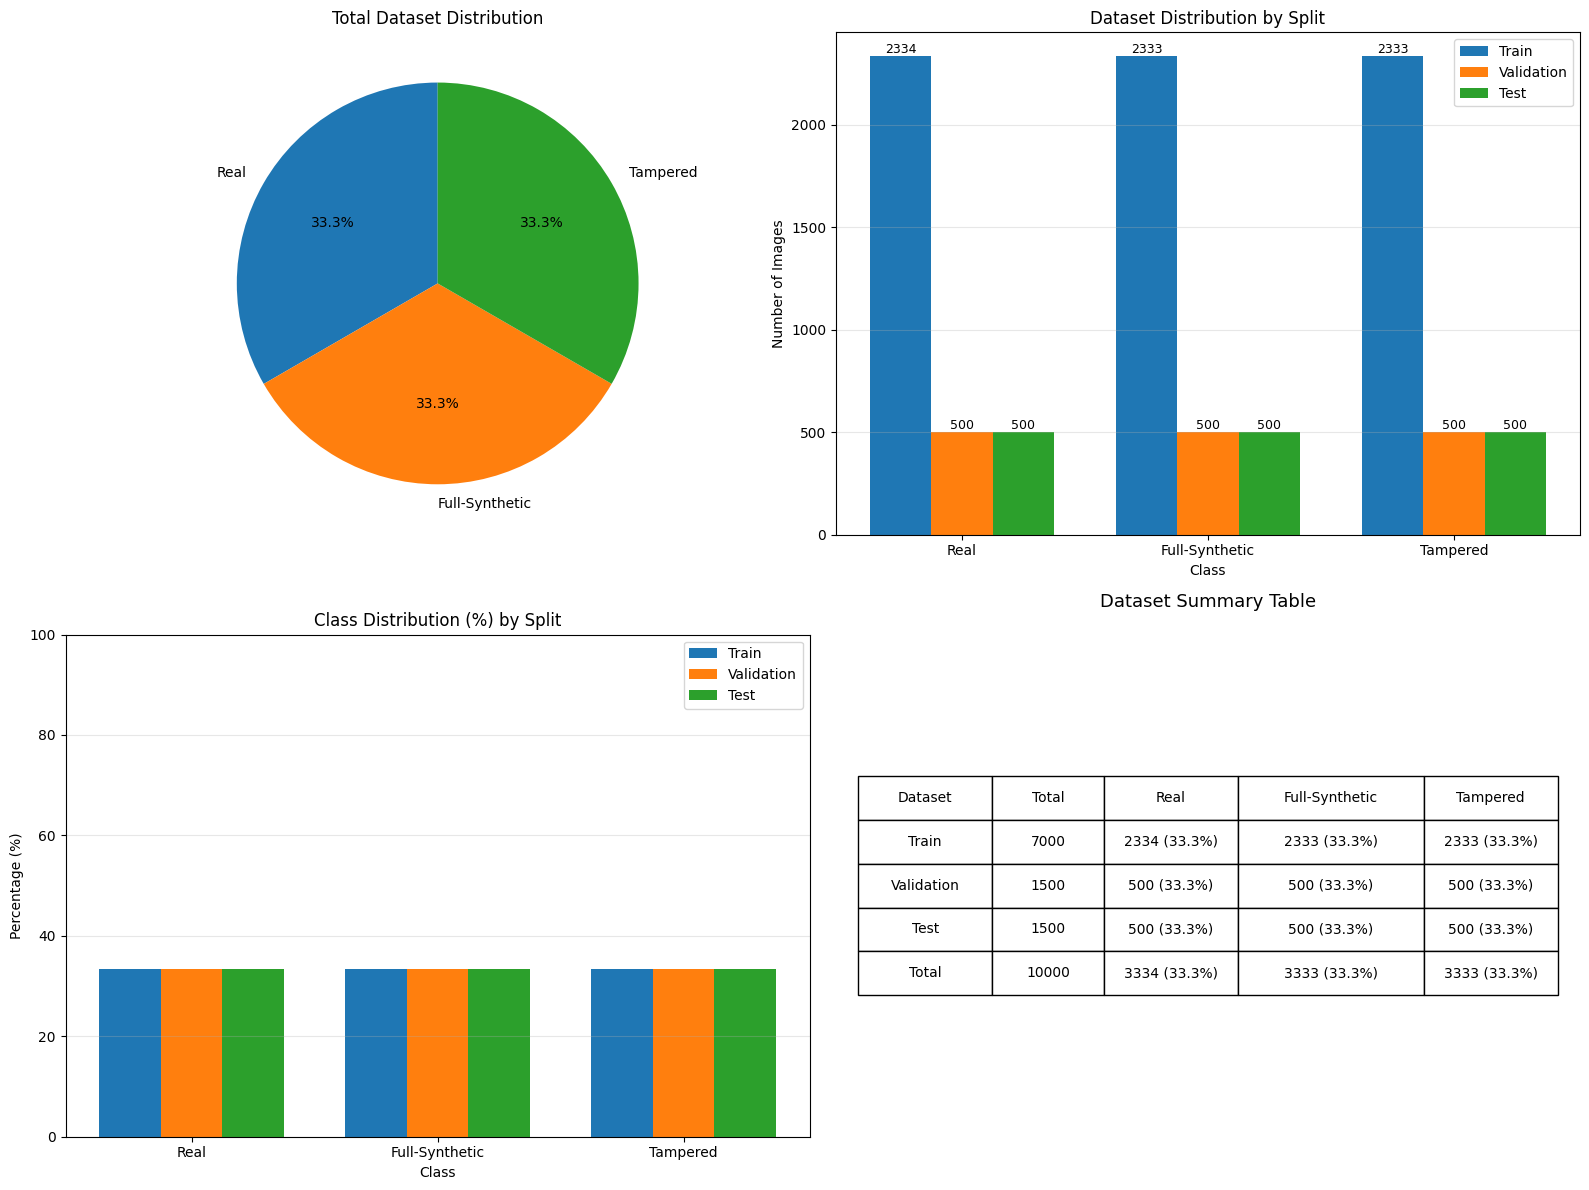


✓ Visualization saved: /content/drive/MyDrive/skripsi/visualizations/dataset_statistics.png


In [ ]:
# Dataset Statistics & Label Distribution Analysis
print("="*80)
print("DATASET STATISTICS & LABEL DISTRIBUTION")
print("="*80)

# Define num_classes
class_names = CLASS_NAMES

# Get label counts for each split
train_label_counts = Counter(y_train)
val_label_counts = Counter(y_val)
test_label_counts = Counter(y_test)
total_label_counts = Counter(y_train + y_val + y_test)

total_images = len(image_paths)

# Create summary table
print("\n" + "=" * 80)
print("DATASET SPLIT")
print("=" * 80)
print(f"Train Set      : {len(X_train):5d} images ({len(X_train) / max(total_images, 1) * 100:5.1f}%)")
print(f"Validation Set : {len(X_val):5d} images ({len(X_val) / max(total_images, 1) * 100:5.1f}%)")
print(f"Test Set       : {len(X_test):5d} images ({len(X_test) / max(total_images, 1) * 100:5.1f}%)")
print("─" * 80)
print(f"Total Dataset  : {total_images:5d} images")

# Detailed label distribution
print("\n" + "="*80)
print("LABEL DISTRIBUTION")
print("="*80)

# Create detailed dataframe
summary_rows = []
for label_id in range(NUM_CLASSES):
    class_name = class_names[label_id]

    train_count = train_label_counts.get(label_id, 0)
    val_count = val_label_counts.get(label_id, 0)
    test_count = test_label_counts.get(label_id, 0)
    total_count = total_label_counts.get(label_id, 0)

    train_pct = train_count / max(len(y_train), 1) * 100
    val_pct = val_count / max(len(y_val), 1) * 100
    test_pct = test_count / max(len(y_test), 1) * 100
    total_pct = total_count / max(total_images, 1) * 100

    summary_rows.append({
        "Class": class_name,
        "Train": f"{train_count:4d} ({train_pct:5.1f}%)",
        "Val": f"{val_count:4d} ({val_pct:5.1f}%)",
        "Test": f"{test_count:4d} ({test_pct:5.1f}%)",
        "Total": f"{total_count:4d} ({total_pct:5.1f}%)",
    })

df_summary = pd.DataFrame(summary_rows)
print("\n" + df_summary.to_string(index=False))

print("\n" + "=" * 80)
print("CLASS BREAKDOWN")
print("=" * 80)

for label_id in range(NUM_CLASSES):
    class_name = class_names[label_id]
    count = total_label_counts.get(label_id, 0)
    pct = count / max(total_images, 1) * 100
    bar = "█" * int(pct / 2)
    print(f"{class_name:20s}: {count:5d} images ({pct:5.1f}%) {bar}")

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Total dataset distribution pie chart
total_counts = [total_label_counts.get(i, 0) for i in range(NUM_CLASSES)]
axes[0, 0].pie(total_counts, labels=class_names, autopct="%1.1f%%", startangle=90)
axes[0, 0].set_title("Total Dataset Distribution")

# Stacked bar chart for train/val/test distribution
x_pos = np.arange(NUM_CLASSES)
width = 0.25
train_counts = [train_label_counts.get(i, 0) for i in range(NUM_CLASSES)]
val_counts = [val_label_counts.get(i, 0) for i in range(NUM_CLASSES)]
test_counts = [test_label_counts.get(i, 0) for i in range(NUM_CLASSES)]

bars1 = axes[0, 1].bar(x_pos - width, train_counts, width, label="Train")
bars2 = axes[0, 1].bar(x_pos, val_counts, width, label="Validation")
bars3 = axes[0, 1].bar(x_pos + width, test_counts, width, label="Test")

axes[0, 1].set_xlabel("Class")
axes[0, 1].set_ylabel("Number of Images")
axes[0, 1].set_title("Dataset Distribution by Split")
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(class_names)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis="y")

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            axes[0, 1].text(bar.get_x() + bar.get_width() / 2, h, f"{int(h)}", ha="center", va="bottom", fontsize=9)

# Percentage distribution by set
train_pcts = [train_label_counts.get(i, 0) / max(len(y_train), 1) * 100 for i in range(NUM_CLASSES)]
val_pcts = [val_label_counts.get(i, 0) / max(len(y_val), 1) * 100 for i in range(NUM_CLASSES)]
test_pcts = [test_label_counts.get(i, 0) / max(len(y_test), 1) * 100 for i in range(NUM_CLASSES)]

axes[1, 0].bar(x_pos - width, train_pcts, width, label="Train")
axes[1, 0].bar(x_pos, val_pcts, width, label="Validation")
axes[1, 0].bar(x_pos + width, test_pcts, width, label="Test")
axes[1, 0].set_xlabel("Class")
axes[1, 0].set_ylabel("Percentage (%)")
axes[1, 0].set_title("Class Distribution (%) by Split")
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(class_names)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis="y")
axes[1, 0].set_ylim([0, 100])

axes[1, 1].axis("off")
table_data = [["Dataset", "Total", "Real", "Full-Synthetic", "Tampered"]]
for split_name, ys, counts in [
    ("Train", y_train, train_label_counts),
    ("Validation", y_val, val_label_counts),
    ("Test", y_test, test_label_counts),
    ("Total", y_train + y_val + y_test, total_label_counts),
]:
    split_total = len(ys)
    table_data.append([
        split_name,
        f"{split_total}",
        f"{counts.get(0, 0)} ({counts.get(0, 0) / max(split_total, 1) * 100:.1f}%)",
        f"{counts.get(1, 0)} ({counts.get(1, 0) / max(split_total, 1) * 100:.1f}%)",
        f"{counts.get(2, 0)} ({counts.get(2, 0) / max(split_total, 1) * 100:.1f}%)",
    ])

table = axes[1, 1].table(
    cellText=table_data,
    cellLoc="center",
    loc="center",
    colWidths=[0.18, 0.15, 0.18, 0.25, 0.18],
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2)
axes[1, 1].set_title("Dataset Summary Table", fontsize=13, pad=20)

plt.tight_layout()

dataset_stats_path = os.path.join(VIS_ROOT, "dataset_statistics.png")
plt.savefig(dataset_stats_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"\n✓ Visualization saved: {dataset_stats_path}")
print("=" * 80)

### Create PyTorch Dataset & DataLoader

In [ ]:
# =============================================================================
# PYTORCH DATASET & DATALOADER
# =============================================================================

class ImageDataset(Dataset):
    """Load image files on demand."""

    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        try:
            image = Image.open(img_path)
            if image.mode != 'RGB':
                image = image.convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image, self.labels[idx]
        except Exception as e:
            print(f"Warning: Failed to load {img_path}: {e}")
            fallback = Image.new('RGB', (224, 224), (0, 0, 0))
            if self.transform:
                fallback = self.transform(fallback)
            return fallback, self.labels[idx]

# Train transform
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))], p=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.10, scale=(0.02, 0.10)),
])

# Validation/test transform
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
test_transform = val_transform  # same as val

# Datasets
print("Creating PyTorch datasets...")
train_dataset = ImageDataset(X_train, y_train, transform=train_transform)
val_dataset   = ImageDataset(X_val,   y_val,   transform=val_transform)
test_dataset  = ImageDataset(X_test,  y_test,  transform=test_transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"  Train batches : {len(train_loader)}")
print(f"  Val   batches : {len(val_loader)}")
print(f"  Test  batches : {len(test_loader)}")

Creating PyTorch datasets...
  Train batches : 219
  Val   batches : 47
  Test  batches : 47


In [ ]:
# =============================================================================
# BINARY IMAGE TEST DATALOADER
# =============================================================================

binary_test_dataset = ImageDataset(
    X_test_binary,
    y_test_binary_3class,
    transform=test_transform,
)

binary_test_loader = DataLoader(
    binary_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

print("✓ Binary image test loader created")
print(f"   Samples : {len(binary_test_dataset):,}")
print(f"   Batches : {len(binary_test_loader):,}")

✓ Binary image test loader created
   Samples : 1,000
   Batches : 32


### Define Image Classification Model

In [ ]:
# ============================================================================
# IMAGE CLASSIFICATION MODEL
# ============================================================================

class ImageClassifier(nn.Module):
    """3-class image classifier using a selectable timm backbone."""

    def __init__(self, num_classes=NUM_CLASSES, model_name=None, pretrained=True, dropout_rate=0.5):
        super().__init__()

        if model_name is None:
            raise ValueError("model_name must be provided. Run model selection first.")

        self.model_name = model_name

        print(f"Loading image backbone: {model_name}")
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=0)

        self.feature_dim = self.backbone.num_features
        print(f"Feature dimension: {self.feature_dim}")

        # Classification head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(self.feature_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.8),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.6),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

    def get_features(self, x):
        return self.backbone(x)

def build_model(model_name=None, num_classes=NUM_CLASSES, dropout_rate=0.5, pretrained=True):
    """Build an image classifier from the selected backbone."""
    if model_name is None:
        raise ValueError("model_name has not been selected. Run the IMAGE MODEL SELECTION cell first.")

    model_mapping = {
        "efficientnet_b4": "efficientnet_b4",
        "efficientnet-b4": "efficientnet_b4",
        "resnet50": "resnet50",
        "resnet-50": "resnet50",
        "efficientnet_b0": "efficientnet_b0",
        "efficientnet-b0": "efficientnet_b0",
    }

    actual_model_name = model_mapping.get(str(model_name).lower(), model_name)

    return ImageClassifier(
        num_classes=num_classes,
        model_name=actual_model_name,
        pretrained=pretrained,
        dropout_rate=dropout_rate,
    )

print("✓ ImageClassifier is ready.")

✓ ImageClassifier is ready.


In [ ]:
# ============================================================================
# IMAGE MODEL SELECTION
# ============================================================================

SEL_EPOCHS          = 15
SEL_LEARNING_RATE   = 1e-4
SEL_WEIGHT_DECAY    = 1e-4
SEL_LABEL_SMOOTHING = 0.05
SEL_EARLY_STOP      = 3
SEL_ROOT            = os.path.join(EXPERIMENT_ROOT, "selection_image")
os.makedirs(SEL_ROOT, exist_ok=True)

def _safe_name(name):
    """Create a filesystem-safe name for experiment folders."""
    return str(name).lower().replace(" ", "_").replace("-", "_").replace("/", "_")

def sel_train_epoch(model, loader, criterion, optimizer):
    """Run one training epoch for image model selection."""
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    avg_loss = running_loss / max(len(loader), 1)
    accuracy = 100.0 * correct / max(total, 1)
    return avg_loss, accuracy

@torch.no_grad()
def sel_evaluate(model, loader):
    """Evaluate multiclass and binary Real/Fake metrics on one loader."""
    model.eval()
    all_preds, all_labels = [], []

    for images, labels in tqdm(loader, desc="Validation", leave=False):
        images = images.to(device, non_blocking=True)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    val_acc = accuracy_score(all_labels, all_preds) * 100
    val_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    binary_labels = (all_labels != 0).astype(int)
    binary_preds = (all_preds != 0).astype(int)
    binary_acc = accuracy_score(binary_labels, binary_preds) * 100
    binary_f1 = f1_score(binary_labels, binary_preds, zero_division=0)

    return {
        "val_acc": val_acc,
        "val_f1": val_f1,
        "binary_acc": binary_acc,
        "binary_f1": binary_f1,
    }

def run_image_selection(candidate_name, backbone_name):
    """Train one image candidate and return its best validation metrics."""
    print("=" * 80)
    print(f"[IMAGE SELECTION] Candidate: {candidate_name} | Backbone: {backbone_name}")
    print("=" * 80)

    set_seed(RANDOM_SEED)
    start_time = time.time()

    candidate_model = build_model(
        model_name=backbone_name,
        num_classes=NUM_CLASSES,
        dropout_rate=0.5,
        pretrained=True,
    ).to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=SEL_LABEL_SMOOTHING)
    optimizer = torch.optim.AdamW(
        candidate_model.parameters(),
        lr=SEL_LEARNING_RATE,
        weight_decay=SEL_WEIGHT_DECAY,
    )

    total_params = sum(p.numel() for p in candidate_model.parameters())
    run_name = os.path.join("selection_image", _safe_name(candidate_name))
    _, ckpt_dir, report_dir, _ = make_run_dirs(run_name)

    best = {"val_f1": -1.0}
    history = []
    patience_counter = 0

    for epoch in range(1, SEL_EPOCHS + 1):
        train_loss, train_acc = sel_train_epoch(candidate_model, train_loader, criterion, optimizer)
        val_metrics = sel_evaluate(candidate_model, val_loader)

        epoch_record = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            **val_metrics,
        }
        history.append(epoch_record)

        print(
            f"  Epoch {epoch:02d}/{SEL_EPOCHS} | "
            f"train_acc {train_acc:5.2f}% | "
            f"val_acc {val_metrics['val_acc']:5.2f}% | "
            f"val_f1 {val_metrics['val_f1']:.4f} | "
            f"binary_acc {val_metrics['binary_acc']:5.2f}%"
        )

        if val_metrics["val_f1"] > best["val_f1"]:
            best = {**val_metrics, "best_epoch": epoch}
            patience_counter = 0
            torch.save(
                {
                    "model_state_dict": candidate_model.state_dict(),
                    "candidate_model": candidate_name,
                    "backbone": backbone_name,
                    "metrics": best,
                    "selection_config": {
                        "epochs": SEL_EPOCHS,
                        "learning_rate": SEL_LEARNING_RATE,
                        "weight_decay": SEL_WEIGHT_DECAY,
                        "label_smoothing": SEL_LABEL_SMOOTHING,
                        "early_stopping_patience": SEL_EARLY_STOP,
                    },
                },
                os.path.join(ckpt_dir, "best.pth"),
            )
        else:
            patience_counter += 1
            if patience_counter >= SEL_EARLY_STOP:
                print(f"  Early stopping at epoch {epoch}")
                break

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    with open(os.path.join(report_dir, "history.json"), "w") as f:
        json.dump(history, f, indent=2)

    elapsed_min = (time.time() - start_time) / 60.0

    del candidate_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "model": candidate_name,
        "backbone": backbone_name,
        "params_M": round(total_params / 1e6, 2),
        "val_acc": best["val_acc"],
        "val_f1": best["val_f1"],
        "binary_acc": best["binary_acc"],
        "binary_f1": best["binary_f1"],
        "best_epoch": best["best_epoch"],
        "training_time_min": round(elapsed_min, 2),
    }

image_selection_results = []
for candidate_name, backbone_name in IMAGE_SELECTION_MODELS.items():
    image_selection_results.append(run_image_selection(candidate_name, backbone_name))

image_selection_df = pd.DataFrame(image_selection_results)
image_selection_df = image_selection_df.sort_values("val_f1", ascending=False).reset_index(drop=True)

csv_path = os.path.join(SEL_ROOT, "image_model_comparison.csv")
image_selection_df.to_csv(csv_path, index=False)

print("\n" + "=" * 80)
print("IMAGE MODEL SELECTION RESULTS")
print("=" * 80)
print(image_selection_df.round(4).to_string(index=False))
print(f"\nSaved CSV: {csv_path}")

SELECTED_IMAGE_MODEL = image_selection_df.iloc[0]["model"]
SELECTED_IMAGE_BACKBONE = image_selection_df.iloc[0]["backbone"]
MODEL_NAME = SELECTED_IMAGE_BACKBONE

print("\nSelected image backbone")
print(f"  Model    : {SELECTED_IMAGE_MODEL}")
print(f"  Backbone : {SELECTED_IMAGE_BACKBONE}")


[IMAGE SELECTION] Candidate: EfficientNet-B4 | Backbone: efficientnet_b4
Loading image backbone: efficientnet_b4


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Feature dimension: 1792


Training:   0%|          | 0/219 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/47 [00:00<?, ?it/s]

  Epoch 09/15 | train_acc 95.77% | val_acc 84.40% | val_f1 0.8432 | binary_acc 84.73%


Training:   0%|          | 0/219 [00:00<?, ?it/s]

Validation:   0%|          | 0/47 [00:00<?, ?it/s]

  Epoch 10/15 | train_acc 96.14% | val_acc 84.60% | val_f1 0.8445 | binary_acc 84.87%
  Early stopping at epoch 10

IMAGE MODEL SELECTION RESULTS
          model        backbone  params_M  val_acc  val_f1  binary_acc  binary_f1  best_epoch  training_time_min
EfficientNet-B0 efficientnet_b0      5.85  85.8000  0.8566        86.4     0.8966           7              15.78
      ResNet-50        resnet50     26.14  85.5333  0.8542        86.2     0.8986          14              22.98
EfficientNet-B4 efficientnet_b4     19.91  84.3333  0.8416        85.2     0.8910           6              68.65

Saved CSV: /content/drive/MyDrive/skripsi/experiments/selection_image/image_model_comparison.csv

Selected image backbone
  Model    : EfficientNet-B0
  Backbone : efficientnet_b0


IMAGE MODEL COMPARISON TABLE


,model,backbone,params_M,val_f1,val_acc,binary_f1,binary_acc,best_epoch,training_time_min
0,EfficientNet-B0,efficientnet_b0,5.85,0.8566,85.8000,0.8966,86.4,7,15.78
1,ResNet-50,resnet50,26.14,0.8542,85.5333,0.8986,86.2,14,22.98
2,EfficientNet-B4,efficientnet_b4,19.91,0.8416,84.3333,0.8910,85.2,6,68.65


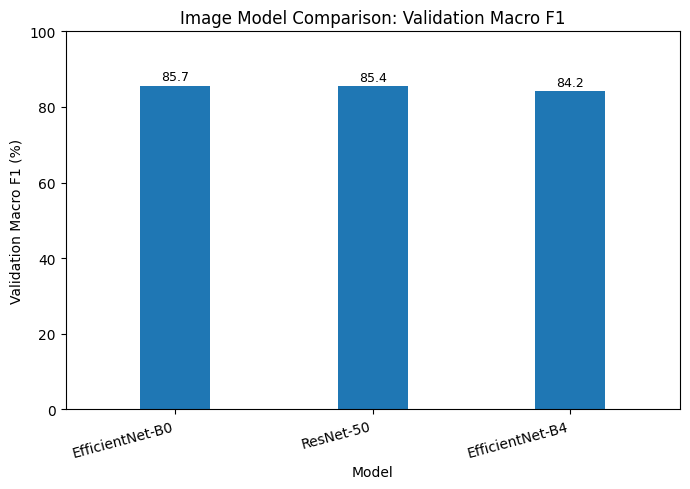

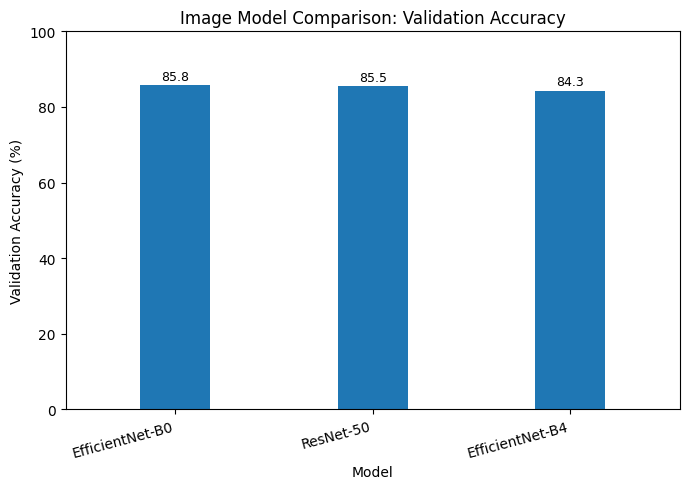

Saved report files:
  Table CSV        : /content/drive/MyDrive/skripsi/experiments/selection_image/image_model_comparison.csv
  Validation F1    : /content/drive/MyDrive/skripsi/experiments/selection_image/image_model_comparison_val_f1.png
  Validation Acc.  : /content/drive/MyDrive/skripsi/experiments/selection_image/image_model_comparison_val_accuracy.png
Selected model     : EfficientNet-B0 (efficientnet_b0)


In [ ]:
# ============================================================================
# IMAGE MODEL SELECTION REPORT
# ============================================================================

if "image_selection_df" not in globals():
    raise RuntimeError("image_selection_df is not available. Run the IMAGE MODEL SELECTION cell first.")

report_df = image_selection_df.copy()
report_df = report_df.sort_values("val_f1", ascending=False).reset_index(drop=True)

# Display a clean table for notebook review
report_table = report_df[[
    "model",
    "backbone",
    "params_M",
    "val_f1",
    "val_acc",
    "binary_f1",
    "binary_acc",
    "best_epoch",
    "training_time_min",
]].copy()

table_csv_path = os.path.join(SEL_ROOT, "image_model_comparison.csv")
report_table.to_csv(table_csv_path, index=False)

print("IMAGE MODEL COMPARISON TABLE")
try:
    display(report_table.round(4))
except NameError:
    print(report_table.round(4).to_string(index=False))

def plot_selection_bar(
    df,
    metric_col,
    title,
    ylabel,
    save_path,
    value_multiplier=1.0,
):
    """Create a compact bar chart for model selection results."""
    x_spacing = 0.45
    bar_width = 0.16

    x = np.arange(len(df)) * x_spacing
    values = df[metric_col].values * value_multiplier

    fig, ax = plt.subplots(figsize=(7, 5))
    bars = ax.bar(
        x,
        values,
        width=bar_width,
    )

    ax.set_title(title)
    ax.set_xlabel("Model")
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 100)

    ax.set_xticks(x)
    ax.set_xticklabels(df["model"], rotation=15, ha="right")

    # Reduce empty horizontal space
    ax.set_xlim(x[0] - 0.25, x[-1] + 0.25)

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.6,
            f"{height:.1f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

# Validation macro F1
f1_fig_path = os.path.join(SEL_ROOT, "image_model_comparison_val_f1.png")
plot_selection_bar(
    df=report_df,
    metric_col="val_f1",
    title="Image Model Comparison: Validation Macro F1",
    ylabel="Validation Macro F1 (%)",
    save_path=f1_fig_path,
    value_multiplier=100.0,
)

# Validation accuracy
acc_fig_path = os.path.join(SEL_ROOT, "image_model_comparison_val_accuracy.png")
plot_selection_bar(
    df=report_df,
    metric_col="val_acc",
    title="Image Model Comparison: Validation Accuracy",
    ylabel="Validation Accuracy (%)",
    save_path=acc_fig_path,
    value_multiplier=1.0,
)

print("Saved report files:")
print(f"  Table CSV        : {table_csv_path}")
print(f"  Validation F1    : {f1_fig_path}")
print(f"  Validation Acc.  : {acc_fig_path}")
print(f"Selected model     : {SELECTED_IMAGE_MODEL} ({SELECTED_IMAGE_BACKBONE})")

### Training Loop with Model Saving

In [ ]:
# ============================================================================
# TRAINING LOOP
# ============================================================================

IMAGE_LR_EXPERIMENTS = {
    "high": {
        "experiment_name": "image_1e-3",
        "learning_rate": 1e-3,
    },
    "base": {
        "experiment_name": "image_1e-4",
        "learning_rate": 1e-4,
    },
    "low": {
        "experiment_name": "image_1e-5",
        "learning_rate": 1e-5,
    },
}

# Pick which learning-rate setting to train with
IMAGE_LR_CHOICE = "base"

if IMAGE_LR_CHOICE not in IMAGE_LR_EXPERIMENTS:
    raise ValueError(f"IMAGE_LR_CHOICE error {list(IMAGE_LR_EXPERIMENTS.keys())}")

CURRENT_EXP = IMAGE_LR_EXPERIMENTS[IMAGE_LR_CHOICE]
EPOCHS = 15
LEARNING_RATE = CURRENT_EXP["learning_rate"]
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.05
EARLY_STOPPING_PATIENCE = 3

experiment_name = CURRENT_EXP["experiment_name"]
RUN_DIR, CHECKPOINT_DIR, REPORT_DIR, VIS_DIR = make_run_dirs(experiment_name)

if MODEL_NAME is None:
    raise RuntimeError("MODEL_NAME is not set.")

experiment_config = {
    "model_family": "image",
    "architecture": "ImageClassifier",
    "selected_model": SELECTED_IMAGE_MODEL,
    "selected_backbone": MODEL_NAME,
    "experiment_name": experiment_name,
    "learning_rate": LEARNING_RATE,
    "learning_rate_choice": IMAGE_LR_CHOICE,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "weight_decay": WEIGHT_DECAY,
    "label_smoothing": LABEL_SMOOTHING,
    "img_size": IMG_SIZE,
    "num_classes": NUM_CLASSES,
    "class_names": CLASS_NAMES,
    "augmentation": "standard",
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}
with open(os.path.join(RUN_DIR, "config.json"), "w") as f:
    json.dump(experiment_config, f, indent=2)

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    pbar = tqdm(loader, desc="Training")
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        # Clip gradients to keep training stable
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
        pbar.set_postfix({"loss": f"{loss.item():.4f}", "acc": f"{100*correct/max(total,1):.2f}%"})

    return running_loss / max(len(loader), 1), 100.0 * correct / max(total, 1)

def validate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation"):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)
            preds = torch.argmax(outputs, dim=1)

            running_loss += loss.item()
            total += labels.size(0)
            correct += (preds == labels).sum().item()
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    val_loss = running_loss / max(len(loader), 1)
    val_acc = 100.0 * correct / max(total, 1)
    val_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return val_loss, val_acc, val_f1, all_preds, all_labels

def save_checkpoint(model, optimizer, scheduler, epoch, metrics, is_best=False):
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
        "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
        "metrics": metrics,
        "history": history,
        "experiment_config": experiment_config,
        "model_metadata": {
            "model_family": "image",
            "architecture": "ImageClassifier",
    "selected_model": SELECTED_IMAGE_MODEL,
    "selected_backbone": MODEL_NAME,
            "num_classes": NUM_CLASSES,
            "class_names": experiment_config["class_names"],
            "img_size": IMG_SIZE,
            "dropout_rate": 0.5,
        },
    }

    epoch_path = os.path.join(CHECKPOINT_DIR, f"epoch_{epoch:03d}.pth")
    last_path = os.path.join(CHECKPOINT_DIR, "last.pth")
    torch.save(checkpoint, epoch_path)
    torch.save(checkpoint, last_path)

    if is_best:
        best_path = os.path.join(CHECKPOINT_DIR, "best.pth")
        torch.save(checkpoint, best_path)
        print(f"✓ Best checkpoint saved: {best_path}")

    return epoch_path

# Build the final model from the backbone selected in Stage 1.
model = build_model(model_name=MODEL_NAME, num_classes=NUM_CLASSES, dropout_rate=0.5).to(device)

# Label smoothing softens the targets and reduces overconfidence
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = None

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
    "lr": [],
}

best_val_f1 = -1.0
best_val_loss = float("inf")
best_epoch = 0
early_stopping_counter = 0

print("=" * 80)
print(f"IMAGE TRAINING EXPERIMENT: {experiment_name}")
print("=" * 80)
print(f"Model          : {MODEL_NAME}")
print(f"Learning rate  : {LEARNING_RATE}")
print(f"Epochs         : {EPOCHS}")
print(f"Batch size     : {BATCH_SIZE}")
print(f"Weight decay   : {WEIGHT_DECAY}")
print(f"Label smoothing: {LABEL_SMOOTHING}")
print(f"Run directory  : {RUN_DIR}")
print("=" * 80)

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")
    print("-" * 80)

    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_f1, val_preds, val_labels = validate(model, val_loader, criterion, device)

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(float(train_loss))
    history["train_acc"].append(float(train_acc))
    history["val_loss"].append(float(val_loss))
    history["val_acc"].append(float(val_acc))
    history["val_f1"].append(float(val_f1))
    history["lr"].append(float(current_lr))

    # Best model is selected by validation macro-F1
    is_best = val_f1 > best_val_f1
    if is_best:
        best_val_f1 = val_f1
        best_val_loss = val_loss
        best_epoch = epoch
        early_stopping_counter = 0
        print(f"✓ New best val F1: {best_val_f1:.4f}")
    else:
        early_stopping_counter += 1
        print(f"No val F1 improvement for {early_stopping_counter} epoch(s)")

    metrics = {
        "train_loss": float(train_loss),
        "train_acc": float(train_acc),
        "val_loss": float(val_loss),
        "val_acc": float(val_acc),
        "val_f1": float(val_f1),
        "learning_rate": float(current_lr),
        "best_val_f1": float(best_val_f1),
        "best_epoch": int(best_epoch),
    }

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss  : {val_loss:.4f} | Val Acc  : {val_acc:.2f}% | Val F1: {val_f1:.4f}")
    print(f"LR        : {current_lr:.2e} | Best F1: {best_val_f1:.4f}")

    save_checkpoint(model, optimizer, scheduler, epoch, metrics, is_best=is_best)

    if scheduler is not None:
        scheduler.step(val_loss)

    with open(os.path.join(REPORT_DIR, "training_history.json"), "w") as f:
        json.dump(history, f, indent=2)

    # Stop early when F1 has not improved for the configured patience
    if early_stopping_counter >= EARLY_STOPPING_PATIENCE:
        print(f"\nEarly stopping: no Val F1 improvement for {EARLY_STOPPING_PATIENCE} epoch(s).")
        print(f"Best epoch: {best_epoch} | Best Val F1: {best_val_f1:.4f}")
        break

print("\n" + "=" * 80)
print("IMAGE TRAINING COMPLETE")
print("=" * 80)
print(f"Best Val F1: {best_val_f1:.4f}")
print(f"Best checkpoint  : {os.path.join(CHECKPOINT_DIR, 'best.pth')}")
print(f"Last checkpoint  : {os.path.join(CHECKPOINT_DIR, 'last.pth')}")

Loading image backbone: efficientnet_b0
Feature dimension: 1280
IMAGE TRAINING EXPERIMENT: image_1e-5
Model          : efficientnet_b0
Learning rate  : 1e-05
Epochs         : 15
Batch size     : 32
Weight decay   : 0.0001
Label smoothing: 0.05
Run directory  : /content/drive/MyDrive/skripsi/experiments/image_1e-5

Epoch 1/15
--------------------------------------------------------------------------------


Training:   0%|          | 0/219 [00:00<?, ?it/s]

Validation:   0%|          | 0/47 [00:00<?, ?it/s]

✓ New best val F1: 0.5304
Train Loss: 1.1150 | Train Acc: 39.33%
Val Loss  : 1.0079 | Val Acc  : 56.33% | Val F1: 0.5304
LR        : 1.00e-05 | Best F1: 0.5304
✓ Best checkpoint saved: /content/drive/MyDrive/skripsi/experiments/image_1e-5/checkpoints/best.pth

Epoch 2/15
--------------------------------------------------------------------------------


Training:   0%|          | 0/219 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/47 [00:00<?, ?it/s]

No val F1 improvement for 1 epoch(s)
Train Loss: 0.5093 | Train Acc: 82.39%
Val Loss  : 0.5057 | Val Acc  : 82.00% | Val F1: 0.8175
LR        : 1.00e-05 | Best F1: 0.8266

Epoch 15/15
--------------------------------------------------------------------------------


Training:   0%|          | 0/219 [00:00<?, ?it/s]

Validation:   0%|          | 0/47 [00:00<?, ?it/s]

✓ New best val F1: 0.8314
Train Loss: 0.5042 | Train Acc: 81.90%
Val Loss  : 0.4828 | Val Acc  : 83.27% | Val F1: 0.8314
LR        : 1.00e-05 | Best F1: 0.8314
✓ Best checkpoint saved: /content/drive/MyDrive/skripsi/experiments/image_1e-5/checkpoints/best.pth

IMAGE TRAINING COMPLETE
Best Val F1: 0.8314
Best checkpoint  : /content/drive/MyDrive/skripsi/experiments/image_1e-5/checkpoints/best.pth
Last checkpoint  : /content/drive/MyDrive/skripsi/experiments/image_1e-5/checkpoints/last.pth


## Visualize Training History

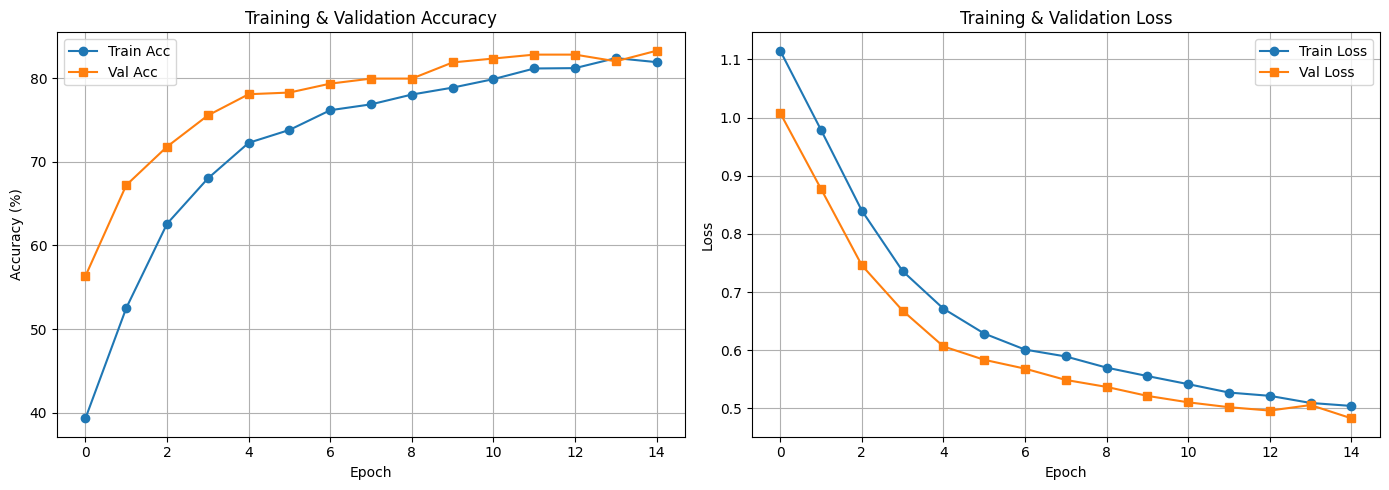

✓ Training history saved to: /content/drive/MyDrive/skripsi/experiments/image_1e-5/visualizations/image_1e-5_history.png


In [ ]:
# ============================================================================
# VISUALIZE TRAINING HISTORY
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history['train_acc'], label='Train Acc', marker='o')
axes[0].plot(history['val_acc'], label='Val Acc', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Training & Validation Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history['train_loss'], label='Train Loss', marker='o')
axes[1].plot(history['val_loss'], label='Val Loss', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training & Validation Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()

history_plot_path = os.path.join(VIS_DIR, f"{experiment_name}_history.png")
plt.savefig(history_plot_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Training history saved to: {history_plot_path}")

In [ ]:
# ============================================================================
# PIPELINE VERIFICATION
# ============================================================================

print("\n" + "=" * 80)
print("IMAGE PIPELINE VERIFICATION")
print("=" * 80)
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# Dataset folders
print("\n" + "-" * 80)
print("Check Dataset")
print("-" * 80)

root = Path(DATASET_DIR)
dataset_label_counts = Counter()
total_images = 0

if root.exists():
    print(f"✓ Dataset root: {DATASET_DIR}")

    for image_class_folder, label_id in IMAGE_CLASS_LABELS.items():
        class_folder_path = root / image_class_folder

        if class_folder_path.exists():
            image_files = [
                image_file_path for image_file_path in class_folder_path.rglob("*")
                if image_file_path.suffix.lower() in IMAGE_EXTENSIONS
            ]
            count = len(image_files)
            dataset_label_counts[label_id] = count
            total_images += count
            print(f"✓ {LABEL_NAMES[label_id]:<20}: {count:6,} images")
        else:
            print(f"✗ {LABEL_NAMES[label_id]:<20}: folder not found ({class_folder_path})")

    print(f"\n✓ Total images found: {total_images:,}")

    if total_images > 0:
        print("\nLabel Distribution:")
        for label_id, label_name in LABEL_NAMES.items():
            count = dataset_label_counts.get(label_id, 0)
            pct = count / max(total_images, 1) * 100
            print(f"  {label_name:<20}: {count:6,} ({pct:5.2f}%)")
else:
    print(f"✗ Dataset directory not found: {DATASET_DIR}")

# Train/val/test splits
print("\n" + "-" * 80)
print("Check Dataset Splits")
print("-" * 80)

total_split = len(X_train) + len(X_val) + len(X_test)
print(f"✓ Train set:  {len(X_train):6,} images ({len(X_train) / max(total_split, 1) * 100:5.1f}%)")
print(f"✓ Val set:    {len(X_val):6,} images ({len(X_val) / max(total_split, 1) * 100:5.1f}%)")
print(f"✓ Test set:   {len(X_test):6,} images ({len(X_test) / max(total_split, 1) * 100:5.1f}%)")
print(f"✓ Total:      {total_split:6,} images")

print("\nLabel distribution in splits:")
for split_name, y_split in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    dist = Counter(y_split)
    print(f"\n{split_name}:")
    for label_id, label_name in LABEL_NAMES.items():
        count = dist.get(label_id, 0)
        pct = count / max(len(y_split), 1) * 100
        print(f"  {label_name:<20}: {count:6,} ({pct:5.2f}%)")

# Dataloaders
print("\n" + "-" * 80)
print("Check DataLoaders")
print("-" * 80)

print(f"✓ Train loader:  {len(train_loader)} batches (batch_size={train_loader.batch_size})")
print(f"✓ Val loader:    {len(val_loader)} batches (batch_size={val_loader.batch_size})")
print(f"✓ Test loader:   {len(test_loader)} batches (batch_size={test_loader.batch_size})")

try:
    sample_images, sample_labels = next(iter(train_loader))
    print(f"\n✓ Sample batch shape: {sample_images.shape}")
    print(f"✓ Sample labels shape: {sample_labels.shape}")
    print(f"✓ Tensor dtype: {sample_images.dtype}")
    print(f"✓ Tensor device: {sample_images.device}")

    if sample_images.ndim == 4:
        print("✓ Input shape looks correct for image model")
    else:
        print("⚠ Warning: sample shape does not look like image input")
except Exception as e:
    print(f"✗ Error loading sample batch: {e}")

# Model
print("\n" + "-" * 80)
print("Check Model")
print("-" * 80)
print(f"  ✓ Architecture     : {MODEL_NAME}")
print(f"  ✓ Total params     : {sum(p.numel() for p in model.parameters()):,}")
print(f"  ✓ Trainable params : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"  ✓ Output classes   : {NUM_CLASSES}  (Real / Full-synthetic / Tampered)")
print(f"  ✓ Mode             : {'eval' if not model.training else 'train'}")

# Training history
print("\n" + "-" * 80)
print("Check History")
print("-" * 80)

epochs_trained = len(history.get("train_loss", []))
print(f"✓ Epochs trained: {epochs_trained}")

if epochs_trained > 0:
    print("\nFinal Training Metrics:")
    print(f"  Train Loss:     {history['train_loss'][-1]:.4f}")
    print(f"  Train Accuracy: {history['train_acc'][-1]:.2f}%")
    print(f"  Val Loss:       {history['val_loss'][-1]:.4f}")
    print(f"  Val Accuracy:   {history['val_acc'][-1]:.2f}%")

    if len(history.get("val_f1", [])) > 0:
        print(f"  Val F1 Score:   {history['val_f1'][-1]:.4f}")

    if len(history.get("lr", [])) > 0:
        print(f"  Last LR:        {history['lr'][-1]:.2e}")

# Checkpoints
print("\n" + "-" * 80)
print("Check Checkpoints")
print("-" * 80)

if os.path.exists(CHECKPOINT_DIR):
    checkpoint_files = [
        checkpoint_file
        for checkpoint_file in os.listdir(CHECKPOINT_DIR)
        if checkpoint_file.endswith(".pth")
    ]

    if checkpoint_files:
        print(f"✓ Model checkpoints found: {len(checkpoint_files)}")
        for checkpoint_file in sorted(checkpoint_files)[-5:]:
            print(f"  • {checkpoint_file}")
    else:
        print("✗ No .pth files found in checkpoint directory")
else:
    print(f"✗ Checkpoint directory not found: {CHECKPOINT_DIR}")

print("✓ IMAGE VERIFICATION COMPLETE")


IMAGE PIPELINE VERIFICATION
Timestamp: 2026-05-13 23:40:42

--------------------------------------------------------------------------------
Check Dataset
--------------------------------------------------------------------------------
✓ Dataset root: /content/drive/MyDrive/skripsi/dataset_image
✓ Real                :  3,334 images
✓ Full-Synthetic      :  3,333 images
✓ Tampered            :  3,333 images

✓ Total images found: 10,000

Label Distribution:
  Real                :  3,334 (33.34%)
  Full-Synthetic      :  3,333 (33.33%)
  Tampered            :  3,333 (33.33%)

--------------------------------------------------------------------------------
Check Dataset Splits
--------------------------------------------------------------------------------
✓ Train set:   7,000 images ( 70.0%)
✓ Val set:     1,500 images ( 15.0%)
✓ Test set:    1,500 images ( 15.0%)
✓ Total:      10,000 images

Label distribution in splits:

Train:
  Real                :  2,334 (33.34%)
  Full-Syntheti

In [ ]:
# ============================================================================
# LOAD BEST IMAGE CHECKPOINT
# ============================================================================

# Set this to an experiment name only when you intentionally want to evaluate a different checkpoint.
MANUAL_BEST_EXPERIMENT = None

BEST_EXPERIMENT = MANUAL_BEST_EXPERIMENT if MANUAL_BEST_EXPERIMENT is not None else experiment_name

RUN_DIR, CHECKPOINT_DIR, REPORT_DIR, VIS_DIR = make_run_dirs(BEST_EXPERIMENT)
BEST_CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "best.pth")

if not os.path.exists(BEST_CHECKPOINT_PATH):
    raise FileNotFoundError(f"Best checkpoint not found: {BEST_CHECKPOINT_PATH}")

if "model" not in globals():
    model = build_model(model_name=MODEL_NAME, num_classes=NUM_CLASSES, dropout_rate=0.5)
    model = model.to(device)

checkpoint = torch.load(BEST_CHECKPOINT_PATH, map_location=device)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model = model.to(device)
model.eval()

experiment_name = BEST_EXPERIMENT

print("✓ Best image checkpoint loaded")
print(f"Experiment : {experiment_name}")
print(f"Checkpoint : {BEST_CHECKPOINT_PATH}")

✓ Best image checkpoint loaded
Experiment : image_1e-4
Checkpoint : /content/drive/MyDrive/skripsi/experiments/image_1e-4/checkpoints/best.pth


## Image Evaluation

In [ ]:
# ============================================================================
# IMAGE EVALUATION HELPERS
# ============================================================================

def set_eval_model():
    """Put the image model on the selected device and switch it to eval mode."""
    model.to(device)
    model.eval()
    return model


def weighted_metrics(y_true, y_pred):
    """Return weighted accuracy, precision, recall, and F1."""
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
    }

def plot_confusion(cm, class_names, title, save_path, show=True):
    """Plot and save a confusion matrix with a consistent format."""
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.title(title, fontsize=13, fontweight="normal")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close()

def save_eval_outputs(eval_name, metrics_summary, report_dict, cm, class_names, pred_rows):
    """Save metrics, classification report, confusion matrix, and predictions."""
    os.makedirs(REPORT_DIR, exist_ok=True)
    os.makedirs(VIS_DIR, exist_ok=True)

    metrics_path = os.path.join(REPORT_DIR, f"{eval_name}_metrics.json")
    report_path = os.path.join(REPORT_DIR, f"{eval_name}_classification_report.csv")
    cm_csv_path = os.path.join(REPORT_DIR, f"{eval_name}_confusion_matrix.csv")
    pred_path = os.path.join(REPORT_DIR, f"{eval_name}_predictions.csv")
    cm_png_path = os.path.join(VIS_DIR, f"{eval_name}_confusion_matrix.png")

    with open(metrics_path, "w") as f:
        json.dump(metrics_summary, f, indent=2)

    pd.DataFrame(report_dict).transpose().to_csv(report_path)
    pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(cm_csv_path)
    pd.DataFrame(pred_rows).to_csv(pred_path, index=False)

    return {
        "metrics": metrics_path,
        "classification_report": report_path,
        "confusion_matrix_csv": cm_csv_path,
        "predictions": pred_path,
        "confusion_matrix_png": cm_png_path,
    }

def probs_to_binary(probs_3class):
    """Convert image model probabilities from 3-class format to Real/Fake."""
    prob_real = probs_3class[:, 0]
    prob_fake = probs_3class[:, 1] + probs_3class[:, 2]

    binary_probs = torch.stack([prob_real, prob_fake], dim=1)
    binary_preds = torch.argmax(binary_probs, dim=1)

    return binary_probs, binary_preds

def predict_image_file(image_path):
    """Run the image model on one image and return binary prediction."""
    img = Image.open(image_path).convert("RGB")
    x = val_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        probs_3class = F.softmax(logits, dim=1)
        binary_probs, binary_preds = probs_to_binary(probs_3class)

    prob_real = float(binary_probs[0, 0].detach().cpu())
    prob_fake = float(binary_probs[0, 1].detach().cpu())
    pred = int(binary_preds[0].detach().cpu())
    conf = max(prob_real, prob_fake)

    return pred, conf, prob_real, prob_fake

def extract_video_frames(video_path, num_frames=16, max_duration=8.0):
    """Extract video frames only for cross-domain and mixed-input evaluation."""
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None

    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)

    if fps <= 0 or total_frames <= 0:
        cap.release()
        return None

    duration = total_frames / fps
    effective_duration = min(duration, max_duration)
    effective_frames = max(1, int(effective_duration * fps))

    if effective_frames < num_frames:
        frame_indices = list(range(effective_frames)) + [effective_frames - 1] * (num_frames - effective_frames)
    else:
        frame_indices = np.linspace(0, effective_frames - 1, num_frames, dtype=int)

    frames = []
    for frame_idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
        ok, frame = cap.read()

        if ok:
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        elif len(frames) > 0:
            frames.append(frames[-1])

    cap.release()

    return frames if len(frames) > 0 else None

def predict_video_file(video_path, num_frames=16, max_duration=8.0):
    """Evaluate the image model on video frames for cross-domain testing."""
    frames = extract_video_frames(video_path, num_frames=num_frames, max_duration=max_duration)
    if frames is None:
        return None

    tensors = [
        val_transform(Image.fromarray(frame).convert("RGB"))
        for frame in frames
    ]
    batch = torch.stack(tensors).to(device)

    with torch.no_grad():
        logits = model(batch)
        probs_3class = F.softmax(logits, dim=1)

    avg_probs = probs_3class.mean(dim=0, keepdim=True)
    binary_probs, binary_preds = probs_to_binary(avg_probs)

    prob_real = float(binary_probs[0, 0].detach().cpu())
    prob_fake = float(binary_probs[0, 1].detach().cpu())
    pred = int(binary_preds[0].detach().cpu())
    conf = max(prob_real, prob_fake)

    return pred, conf, prob_real, prob_fake

def list_video_files(root_dir):
    """Fallback helper for optional video-test evaluation when no manifest exists."""
    rows = []
    for folder, label in [("real", 0), ("fake", 1)]:
        class_dir = Path(root_dir) / folder
        if not class_dir.exists():
            continue

        for p in sorted(class_dir.rglob("*")):
            if p.suffix.lower() in VIDEO_EXTENSIONS:
                rows.append({
                    "file_path": str(p),
                    "video_path": str(p),
                    "label": int(label),
                    "class_name": BINARY_NAMES[int(label)],
                })

    return pd.DataFrame(rows)

def build_video_split(clean_csv_path):
    """Build a deterministic video split only when cross-domain evaluation needs it."""
    if not os.path.exists(clean_csv_path):
        raise FileNotFoundError(f"Video clean CSV not found: {clean_csv_path}")

    video_df = pd.read_csv(clean_csv_path)

    if "video_path" not in video_df.columns or "label" not in video_df.columns:
        raise ValueError("video_clean_dataset.csv must contain video_path and label columns.")

    video_df = video_df.copy()
    video_df["file_path"] = video_df["video_path"]
    video_df["label"] = video_df["label"].astype(int)
    video_df = video_df[video_df["file_path"].map(os.path.exists)].reset_index(drop=True)

    real_records = [(row["file_path"], 0) for _, row in video_df[video_df["label"] == 0].iterrows()]
    fake_records = [(row["file_path"], 1) for _, row in video_df[video_df["label"] == 1].iterrows()]

    n = min(len(real_records), len(fake_records))
    real_records = real_records[:n]
    fake_records = fake_records[:n]

    def split_class(items):
        items = items.copy()
        random.Random(RANDOM_SEED).shuffle(items)

        n_items = len(items)
        train_size = int(n_items * 0.70)
        val_size = int(n_items * 0.15)

        return (
            items[:train_size],
            items[train_size:train_size + val_size],
            items[train_size + val_size:],
        )

    real_train, real_val, real_test = split_class(real_records)
    fake_train, fake_val, fake_test = split_class(fake_records)

    split_items = {
        "train": real_train + fake_train,
        "val": real_val + fake_val,
        "test": real_test + fake_test,
    }

    rng = random.Random(RANDOM_SEED)
    rows = []

    for split_name, items in split_items.items():
        items = items.copy()
        rng.shuffle(items)

        for path, label in items:
            rows.append({
                "file_path": path,
                "video_path": path,
                "media_type": "video",
                "split": split_name,
                "label": int(label),
                "class_name": BINARY_NAMES[int(label)],
            })

    split_df = pd.DataFrame(rows)
    split_df.to_csv(VIDEO_SPLIT_CSV, index=False)

    return split_df


def load_image_test():
    """Return the canonical image test split in binary-compatible form."""
    image_test_df = test_df.copy()
    image_test_df["file_path"] = image_test_df["image_path"]
    image_test_df["media_type"] = "image"
    image_test_df["binary_label"] = image_test_df["label"].apply(to_binary_label)
    return image_test_df


IMAGE TEST SET EVALUATION


Image test:   0%|          | 0/47 [00:00<?, ?it/s]


OVERALL METRICS
Total samples       : 1,500
Accuracy            : 0.8447 (84.47%)
Precision           : 0.8453
Recall              : 0.8447
F1-score            : 0.8430

CLASSIFICATION REPORT
                precision    recall  f1-score   support

          Real       0.75      0.82      0.79       500
Full-Synthetic       0.96      0.99      0.97       500
      Tampered       0.83      0.72      0.77       500

      accuracy                           0.84      1500
     macro avg       0.85      0.84      0.84      1500
  weighted avg       0.85      0.84      0.84      1500


PROCESSING REPORT
Total time          : 532,146.20 ms
Mean batch latency  : 11.38 ms
Mean sample latency : 354.76 ms/image
Throughput          : 2.82 samples/sec
CPU memory delta    : 6.91 MB
GPU allocated       : 568.21 MB
GPU reserved        : 688.00 MB

CONFUSION MATRIX


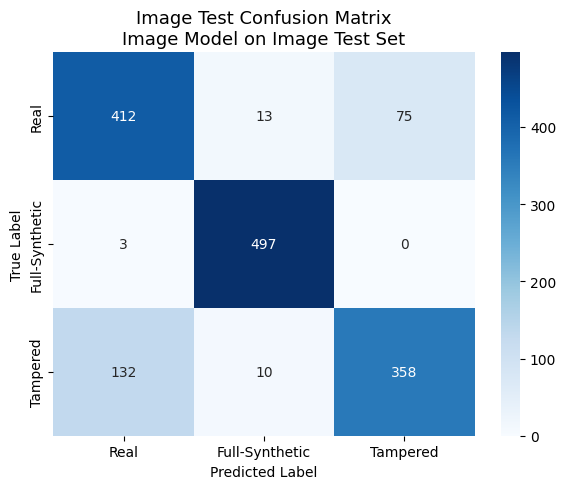


✓ Image test reports saved:
  metrics                 : /content/drive/MyDrive/skripsi/experiments/image_1e-4/reports/image_1e-4_metrics.json
  classification_report   : /content/drive/MyDrive/skripsi/experiments/image_1e-4/reports/image_1e-4_classification_report.csv
  confusion_matrix_csv    : /content/drive/MyDrive/skripsi/experiments/image_1e-4/reports/image_1e-4_confusion_matrix.csv
  predictions             : /content/drive/MyDrive/skripsi/experiments/image_1e-4/reports/image_1e-4_predictions.csv
  confusion_matrix_png    : /content/drive/MyDrive/skripsi/experiments/image_1e-4/visualizations/image_1e-4_confusion_matrix.png


In [ ]:
# ============================================================================
# IMAGE TEST SET EVALUATION
# ============================================================================

print("\n" + "=" * 80)
print("IMAGE TEST SET EVALUATION")
print("=" * 80)

set_eval_model()

CLASS_LABELS = [CLASS_NAMES[i] for i in range(NUM_CLASSES)]

y_true, y_pred = [], []
confidences = []
pred_rows = []

with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(tqdm(test_loader, desc="Image test")):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)
        batch_conf = torch.max(probs, dim=1)[0]

        labels_cpu = labels.detach().cpu().numpy().tolist()
        preds_cpu = preds.detach().cpu().numpy().tolist()
        conf_cpu = batch_conf.detach().cpu().numpy().tolist()
        probs_cpu = probs.detach().cpu().numpy().tolist()

        y_true.extend(labels_cpu)
        y_pred.extend(preds_cpu)
        confidences.extend(conf_cpu)

        for i in range(len(labels_cpu)):
            row = {
                "batch_idx": int(batch_idx),
                "true_label_id": int(labels_cpu[i]),
                "true_label": CLASS_NAMES[int(labels_cpu[i])],
                "pred_label_id": int(preds_cpu[i]),
                "pred_label": CLASS_NAMES[int(preds_cpu[i])],
                "confidence": float(conf_cpu[i]),
            }

            for class_idx, class_name in enumerate(CLASS_LABELS):
                col_name = "prob_" + class_name.lower().replace("-", "_").replace(" ", "_")
                row[col_name] = float(probs_cpu[i][class_idx])

            pred_rows.append(row)

processed_samples = len(y_true)
if processed_samples == 0:
    raise RuntimeError("No valid image samples were processed.")

metrics = weighted_metrics(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

report_text = classification_report(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_LABELS,
    zero_division=0,
)

report_dict = classification_report(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_LABELS,
    output_dict=True,
    zero_division=0,
)

metrics_summary = {
    "experiment_name": experiment_name,
    "model_family": "image",
    "evaluation_type": "image_test_set_3class",
    "input_domain": "image_test_set",
    "image_split_file": IMAGE_SPLIT_CSV,
    "checkpoint_used": BEST_CHECKPOINT_PATH,
    "num_samples": int(processed_samples),
    "processed_samples": int(processed_samples),
    "failed_samples": 0,
    "accuracy": metrics["accuracy"],
    "precision": metrics["precision"],
    "recall": metrics["recall"],
    "f1": metrics["f1"],
    "precision_weighted": metrics["precision"],
    "recall_weighted": metrics["recall"],
    "f1_weighted": metrics["f1"],
}

eval_name = experiment_name

saved_paths = save_eval_outputs(
    eval_name=eval_name,
    metrics_summary=metrics_summary,
    report_dict=report_dict,
    cm=cm,
    class_names=CLASS_LABELS,
    pred_rows=pred_rows,
)

print("\nOVERALL METRICS")
print("=" * 80)
print(f"Total samples       : {processed_samples:,}")
print(f"Accuracy            : {metrics['accuracy']:.4f} ({metrics['accuracy'] * 100:.2f}%)")
print(f"Precision           : {metrics['precision']:.4f}")
print(f"Recall              : {metrics['recall']:.4f}")
print(f"F1-score            : {metrics['f1']:.4f}")

print("\nCLASSIFICATION REPORT")
print("=" * 80)
print(report_text)

print("\nCONFUSION MATRIX")
print("=" * 80)

plot_confusion(
    cm=cm,
    class_names=CLASS_LABELS,
    title="Image Test Confusion Matrix\nImage Model on Image Test Set",
    save_path=saved_paths["confusion_matrix_png"],
    show=True,
)

print("\n✓ Image test reports saved:")
for label, path in saved_paths.items():
    print(f"  {label:<24}: {path}")

## Binary Image Evaluation


BINARY IMAGE TEST SET EVALUATION


Binary image test:   0%|          | 0/32 [00:00<?, ?it/s]


OVERALL METRICS
Total samples       : 1,000
Accuracy            : 0.8490 (84.90%)
Precision           : 0.8505
Recall              : 0.8490
F1-score            : 0.8488

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Real       0.87      0.82      0.84       500
        Fake       0.83      0.88      0.85       500

    accuracy                           0.85      1000
   macro avg       0.85      0.85      0.85      1000
weighted avg       0.85      0.85      0.85      1000


PROCESSING REPORT
Total time          : 7,730.12 ms
Mean batch latency  : 15.18 ms
Mean sample latency : 7.73 ms/image
Throughput          : 129.36 samples/sec
CPU memory delta    : 8.29 MB
GPU allocated       : 568.21 MB
GPU reserved        : 690.00 MB

CONFUSION MATRIX


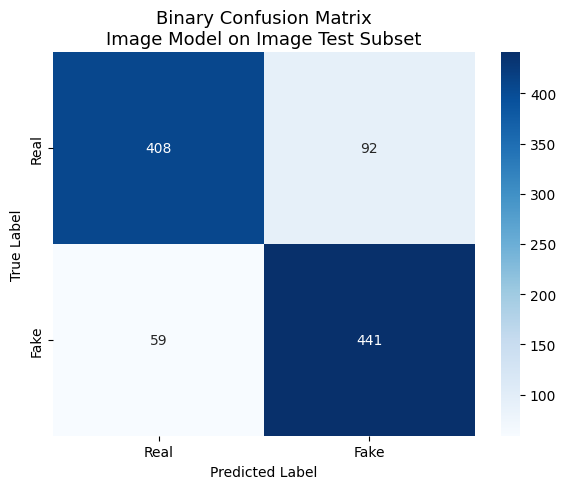


✓ Binary image test reports saved:
  metrics                 : /content/drive/MyDrive/skripsi/experiments/image_1e-4/reports/image_1e-4_binary_metrics.json
  classification_report   : /content/drive/MyDrive/skripsi/experiments/image_1e-4/reports/image_1e-4_binary_classification_report.csv
  confusion_matrix_csv    : /content/drive/MyDrive/skripsi/experiments/image_1e-4/reports/image_1e-4_binary_confusion_matrix.csv
  predictions             : /content/drive/MyDrive/skripsi/experiments/image_1e-4/reports/image_1e-4_binary_predictions.csv
  confusion_matrix_png    : /content/drive/MyDrive/skripsi/experiments/image_1e-4/visualizations/image_1e-4_binary_confusion_matrix.png


In [ ]:
# ============================================================================
# BINARY IMAGE TEST SET EVALUATION
# ============================================================================

print("\n" + "=" * 80)
print("BINARY IMAGE TEST SET EVALUATION")
print("=" * 80)

set_eval_model()

y_true, y_pred = [], []
confidences, real_probs, fake_probs = [], [], []
pred_rows = []

with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(tqdm(binary_test_loader, desc="Binary image test")):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        probs_3class = F.softmax(outputs, dim=1)
        binary_probs, binary_preds = probs_to_binary(probs_3class)

        binary_true = torch.tensor(
            [to_binary_label(label.item()) for label in labels],
            dtype=torch.long,
            device=device,
        )

        batch_conf = torch.max(binary_probs, dim=1)[0]
        preds_3class = torch.argmax(probs_3class, dim=1)

        labels_cpu = labels.detach().cpu().numpy().tolist()
        true_binary_cpu = binary_true.detach().cpu().numpy().tolist()
        pred_binary_cpu = binary_preds.detach().cpu().numpy().tolist()
        pred_3class_cpu = preds_3class.detach().cpu().numpy().tolist()
        conf_cpu = batch_conf.detach().cpu().numpy().tolist()
        real_cpu = binary_probs[:, 0].detach().cpu().numpy().tolist()
        fake_cpu = binary_probs[:, 1].detach().cpu().numpy().tolist()

        y_true.extend(true_binary_cpu)
        y_pred.extend(pred_binary_cpu)
        confidences.extend(conf_cpu)
        real_probs.extend(real_cpu)
        fake_probs.extend(fake_cpu)

        for i in range(len(labels_cpu)):
            pred_rows.append({
                "batch_idx": int(batch_idx),
                "true_3class_id": int(labels_cpu[i]),
                "true_3class": CLASS_NAMES[int(labels_cpu[i])],
                "pred_3class_id": int(pred_3class_cpu[i]),
                "pred_3class": CLASS_NAMES[int(pred_3class_cpu[i])],
                "true_binary_id": int(true_binary_cpu[i]),
                "true_binary": BINARY_NAMES[int(true_binary_cpu[i])],
                "pred_binary_id": int(pred_binary_cpu[i]),
                "pred_binary": BINARY_NAMES[int(pred_binary_cpu[i])],
                "confidence": float(conf_cpu[i]),
                "real_prob": float(real_cpu[i]),
                "fake_prob": float(fake_cpu[i]),
            })

processed_samples = len(y_true)
if processed_samples == 0:
    raise RuntimeError("No valid image samples were processed.")

metrics = weighted_metrics(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

report_text = classification_report(
    y_true,
    y_pred,
    labels=[0, 1],
    target_names=BINARY_NAMES,
    zero_division=0,
)

report_dict = classification_report(
    y_true,
    y_pred,
    labels=[0, 1],
    target_names=BINARY_NAMES,
    output_dict=True,
    zero_division=0,
)

metrics_summary = {
    "experiment_name": experiment_name,
    "model_family": "image",
    "evaluation_type": "binary_balanced_image_test_set",
    "input_domain": "image_test_binary_balanced",
    "image_split_file": IMAGE_SPLIT_CSV,
    "image_binary_input_file": IMAGE_BINARY_INPUT_CSV,
    "checkpoint_used": BEST_CHECKPOINT_PATH,
    "num_samples": int(processed_samples),
    "processed_samples": int(processed_samples),
    "failed_samples": 0,
    "accuracy": metrics["accuracy"],
    "precision": metrics["precision"],
    "recall": metrics["recall"],
    "f1": metrics["f1"],
    "precision_weighted": metrics["precision"],
    "recall_weighted": metrics["recall"],
    "f1_weighted": metrics["f1"],
}

eval_name = f"{experiment_name}_binary"

saved_paths = save_eval_outputs(
    eval_name=eval_name,
    metrics_summary=metrics_summary,
    report_dict=report_dict,
    cm=cm,
    class_names=BINARY_NAMES,
    pred_rows=pred_rows,
)

print("\nOVERALL METRICS")
print("=" * 80)
print(f"Total samples       : {processed_samples:,}")
print(f"Accuracy            : {metrics['accuracy']:.4f} ({metrics['accuracy'] * 100:.2f}%)")
print(f"Precision           : {metrics['precision']:.4f}")
print(f"Recall              : {metrics['recall']:.4f}")
print(f"F1-score            : {metrics['f1']:.4f}")

print("\nCLASSIFICATION REPORT")
print("=" * 80)
print(report_text)

print("\nCONFUSION MATRIX")
print("=" * 80)

plot_confusion(
    cm=cm,
    class_names=BINARY_NAMES,
    title="Binary Confusion Matrix\nImage Model on Image Test Subset",
    save_path=saved_paths["confusion_matrix_png"],
    show=True,
)

print("\n✓ Binary image test reports saved:")
for label, path in saved_paths.items():
    print(f"  {label:<24}: {path}")

## Cross-Domain Evaluation


CROSS-DOMAIN TEST
✓ Loaded video split: /content/drive/MyDrive/skripsi/shared_splits/video_split.csv
Video test samples : 1,500
Video split file   : /content/drive/MyDrive/skripsi/shared_splits/video_split.csv
Checkpoint         : /content/drive/MyDrive/skripsi/experiments/image_1e-4/checkpoints/best.pth


Image model on video test split:   0%|          | 0/1500 [00:00<?, ?it/s]


OVERALL METRICS
Total samples       : 1,500
Processed samples   : 1,500
Failed samples      : 0
Accuracy            : 0.5447 (54.47%)
Precision           : 0.5801
Recall              : 0.5447
F1-score            : 0.4880

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Real       0.53      0.88      0.66       750
        Fake       0.63      0.21      0.32       750

    accuracy                           0.54      1500
   macro avg       0.58      0.54      0.49      1500
weighted avg       0.58      0.54      0.49      1500


PROCESSING REPORT
Total time          : 2,410,110.38 ms
Mean batch latency  : 1,606.74 ms
Mean sample latency : 1,606.74 ms/video
Throughput          : 0.62 samples/sec
CPU memory delta    : 173.29 MB
GPU allocated       : 377.87 MB
GPU reserved        : 442.00 MB

CONFUSION MATRIX


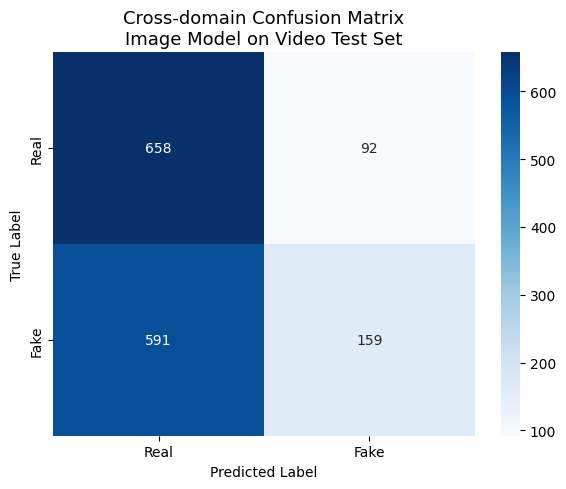


✓ Cross-domain reports saved:
  metrics                 : /content/drive/MyDrive/skripsi/experiments/image_1e-4/reports/image_1e-4_cross_metrics.json
  classification_report   : /content/drive/MyDrive/skripsi/experiments/image_1e-4/reports/image_1e-4_cross_classification_report.csv
  confusion_matrix_csv    : /content/drive/MyDrive/skripsi/experiments/image_1e-4/reports/image_1e-4_cross_confusion_matrix.csv
  predictions             : /content/drive/MyDrive/skripsi/experiments/image_1e-4/reports/image_1e-4_cross_predictions.csv
  confusion_matrix_png    : /content/drive/MyDrive/skripsi/experiments/image_1e-4/visualizations/image_1e-4_cross_confusion_matrix.png


In [ ]:
# ============================================================================
# CROSS-DOMAIN TEST
# ============================================================================

print("\n" + "=" * 80)
print("CROSS-DOMAIN TEST")
print("=" * 80)

set_eval_model()

video_test_df = load_video_test()
test_videos = list(zip(
    video_test_df["file_path"].tolist(),
    video_test_df["label"].astype(int).tolist()
))

print(f"Video test samples : {len(test_videos):,}")
print(f"Video split file   : {VIDEO_SPLIT_CSV}")
print(f"Checkpoint         : {BEST_CHECKPOINT_PATH}")

y_true, y_pred = [], []
confidences, real_probs, fake_probs = [], [], []
paths_used, latencies_ms = [], []
failed = 0

for video_path, label in tqdm(test_videos, desc="Image model on video test split"):
    sample_start = time.perf_counter()

    result = predict_video_file(
        video_path,
        num_frames=16,
        max_duration=8.0,
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    sample_latency_ms = (time.perf_counter() - sample_start) * 1000

    if result is None:
        failed += 1
        continue

    pred_binary, confidence, prob_real, prob_fake = result

    y_true.append(int(label))
    y_pred.append(int(pred_binary))
    confidences.append(float(confidence))
    real_probs.append(float(prob_real))
    fake_probs.append(float(prob_fake))
    paths_used.append(video_path)

if len(y_true) == 0:
    raise RuntimeError("No valid video samples were processed.")

processed_samples = len(y_true)
total_samples = len(test_videos)

metrics = weighted_metrics(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

report_text = classification_report(
    y_true,
    y_pred,
    labels=[0, 1],
    target_names=BINARY_NAMES,
    zero_division=0,
)

report_dict = classification_report(
    y_true,
    y_pred,
    labels=[0, 1],
    target_names=BINARY_NAMES,
    output_dict=True,
    zero_division=0,
)

pred_rows = pd.DataFrame({
    "video_path": paths_used,
    "true_label_id": y_true,
    "true_label": [BINARY_NAMES[i] for i in y_true],
    "pred_label_id": y_pred,
    "pred_label": [BINARY_NAMES[i] for i in y_pred],
    "confidence": confidences,
    "real_prob": real_probs,
    "fake_prob": fake_probs,
}).to_dict("records")

metrics_summary = {
    "experiment_name": experiment_name,
    "model_family": "image",
    "evaluation_type": "cross_domain_image_model_on_video_test_set",
    "input_domain": "canonical_video_test_set",
    "video_split_file": VIDEO_SPLIT_CSV,
    "checkpoint_used": BEST_CHECKPOINT_PATH,
    "num_samples": int(total_samples),
    "processed_samples": int(processed_samples),
    "failed_samples": int(failed),
    "accuracy": metrics["accuracy"],
    "precision": metrics["precision"],
    "recall": metrics["recall"],
    "f1": metrics["f1"],
    "precision_weighted": metrics["precision"],
    "recall_weighted": metrics["recall"],
    "f1_weighted": metrics["f1"],
}

eval_name = f"{experiment_name}_cross"

saved_paths = save_eval_outputs(
    eval_name=eval_name,
    metrics_summary=metrics_summary,
    report_dict=report_dict,
    cm=cm,
    class_names=BINARY_NAMES,
    pred_rows=pred_rows,
)

print("\nOVERALL METRICS")
print("=" * 80)
print(f"Total samples       : {total_samples:,}")
print(f"Processed samples   : {processed_samples:,}")
print(f"Failed samples      : {failed:,}")
print(f"Accuracy            : {metrics['accuracy']:.4f} ({metrics['accuracy'] * 100:.2f}%)")
print(f"Precision           : {metrics['precision']:.4f}")
print(f"Recall              : {metrics['recall']:.4f}")
print(f"F1-score            : {metrics['f1']:.4f}")

print("\nCLASSIFICATION REPORT")
print("=" * 80)
print(report_text)

print("\nCONFUSION MATRIX")
print("=" * 80)

plot_confusion(
    cm=cm,
    class_names=BINARY_NAMES,
    title="Cross-domain Confusion Matrix\nImage Model on Video Test Set",
    save_path=saved_paths["confusion_matrix_png"],
    show=True,
)

print("\n✓ Cross-domain reports saved:")
for label, path in saved_paths.items():
    print(f"  {label:<24}: {path}")

## Mixed-Input Evaluation


IMAGE MODEL MIXED-INPUT TEST
Image samples : 750
Video samples : 750
Mixed samples : 1,500
Mixed CSV     : /content/drive/MyDrive/skripsi/shared_splits/mixed_input.csv
Checkpoint    : /content/drive/MyDrive/skripsi/experiments/image_1e-4/checkpoints/best.pth

Image binary distribution:
true_label
Real    375
Fake    375

Video binary distribution:
true_label
Real    375
Fake    375


Image model on shared mixed-input test:   0%|          | 0/1500 [00:00<?, ?it/s]


OVERALL METRICS
Total samples       : 1,500
Processed samples   : 1,500
Failed samples      : 0
Image samples       : 750
Video samples       : 750
Accuracy            : 0.6940 (69.40%)
Precision           : 0.7132
Recall              : 0.6940
F1-score            : 0.6870

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Real       0.65      0.84      0.73       750
        Fake       0.78      0.54      0.64       750

    accuracy                           0.69      1500
   macro avg       0.71      0.69      0.69      1500
weighted avg       0.71      0.69      0.69      1500


PROCESSING REPORT
Total time          : 546,200.08 ms
Mean batch latency  : 364.13 ms
Mean sample latency : 364.13 ms/input
Throughput          : 2.75 samples/sec
CPU memory delta    : 10.95 MB
GPU allocated       : 377.87 MB
GPU reserved        : 442.00 MB

CONFUSION MATRIX


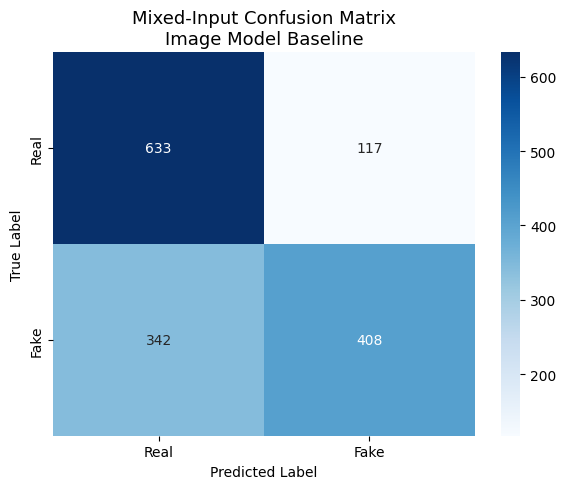


✓ Mixed-input reports saved:
  metrics                 : /content/drive/MyDrive/skripsi/experiments/image_1e-4/reports/image_1e-4_mixed_metrics.json
  classification_report   : /content/drive/MyDrive/skripsi/experiments/image_1e-4/reports/image_1e-4_mixed_classification_report.csv
  confusion_matrix_csv    : /content/drive/MyDrive/skripsi/experiments/image_1e-4/reports/image_1e-4_mixed_confusion_matrix.csv
  predictions             : /content/drive/MyDrive/skripsi/experiments/image_1e-4/reports/image_1e-4_mixed_predictions.csv
  confusion_matrix_png    : /content/drive/MyDrive/skripsi/experiments/image_1e-4/visualizations/image_1e-4_mixed_confusion_matrix.png


In [ ]:
# ============================================================================
# MIXED-INPUT TEST
# ============================================================================

print("\n" + "=" * 80)
print("IMAGE MODEL MIXED-INPUT TEST")
print("=" * 80)

set_eval_model()

mixed_df = pd.read_csv(MIXED_INPUT_CSV)
mixed_df["true_label"] = mixed_df["true_label"].astype(int)

mixed_items = [
    {
        "file_path": row["file_path"],
        "media_type": row["media_type"],
        "true_label": int(row["true_label"]),
    }
    for _, row in mixed_df.iterrows()
]

image_sample_df = mixed_df[mixed_df["media_type"] == "image"].reset_index(drop=True)
video_sample_df = mixed_df[mixed_df["media_type"] == "video"].reset_index(drop=True)

print(f"Image samples : {len(image_sample_df):,}")
print(f"Video samples : {len(video_sample_df):,}")
print(f"Mixed samples : {len(mixed_items):,}")
print(f"Mixed CSV     : {MIXED_INPUT_CSV}")
print(f"Checkpoint    : {BEST_CHECKPOINT_PATH}")

print("\nImage binary distribution:")
print(
    image_sample_df["true_label"]
    .value_counts()
    .sort_index()
    .rename(index={0: "Real", 1: "Fake"})
    .to_string()
)

print("\nVideo binary distribution:")
print(
    video_sample_df["true_label"]
    .value_counts()
    .sort_index()
    .rename(index={0: "Real", 1: "Fake"})
    .to_string()
)

y_true, y_pred = [], []
confidences, real_probs, fake_probs = [], [], []
pred_rows = []
failed = 0

for item in tqdm(mixed_items, desc="Image model on shared mixed-input test"):
    sample_start = time.perf_counter()

    try:
        if item["media_type"] == "image":
            pred, conf, prob_real, prob_fake = predict_image_file(item["file_path"])
        else:
            pred, conf, prob_real, prob_fake = predict_video_file(
                item["file_path"],
                num_frames=16,
                max_duration=8.0,
            )

        success = True
        error = None

    except Exception as e:
        pred = -1
        conf = np.nan
        prob_real = np.nan
        prob_fake = np.nan
        success = False
        error = str(e)
        failed += 1

    if success:
        y_true.append(int(item["true_label"]))
        y_pred.append(int(pred))
        confidences.append(float(conf))
        real_probs.append(float(prob_real))
        fake_probs.append(float(prob_fake))

    pred_rows.append({
        "file_path": item["file_path"],
        "media_type": item["media_type"],
        "true_label_id": int(item["true_label"]),
        "true_label": BINARY_NAMES[int(item["true_label"])],
        "pred_label_id": int(pred) if pred in [0, 1] else -1,
        "pred_label": BINARY_NAMES[int(pred)] if pred in [0, 1] else "Failed",
        "confidence": float(conf) if not pd.isna(conf) else np.nan,
        "prob_real": float(prob_real) if not pd.isna(prob_real) else np.nan,
        "prob_fake": float(prob_fake) if not pd.isna(prob_fake) else np.nan,
        "success": bool(success),
        "error": error,
    })

if len(y_true) == 0:
    raise RuntimeError("No valid mixed samples were processed.")

total_samples = len(mixed_items)
processed_samples = len(y_true)
failed_samples = failed

metrics = weighted_metrics(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

report_text = classification_report(
    y_true,
    y_pred,
    labels=[0, 1],
    target_names=BINARY_NAMES,
    zero_division=0,
)

report_dict = classification_report(
    y_true,
    y_pred,
    labels=[0, 1],
    target_names=BINARY_NAMES,
    output_dict=True,
    zero_division=0,
)

metrics_summary = {
    "experiment_name": experiment_name,
    "model_family": "image",
    "evaluation_type": "shared_mixed_input_test",
    "input_domain": "shared_mixed_image_video",
    "image_split_file": IMAGE_SPLIT_CSV,
    "image_binary_input_file": IMAGE_BINARY_INPUT_CSV,
    "video_split_file": VIDEO_SPLIT_CSV,
    "mixed_input_file": MIXED_INPUT_CSV,
    "checkpoint_used": BEST_CHECKPOINT_PATH,
    "num_samples": int(total_samples),
    "processed_samples": int(processed_samples),
    "failed_samples": int(failed_samples),
    "num_image_samples": int(len(image_sample_df)),
    "num_video_samples": int(len(video_sample_df)),
    "accuracy": metrics["accuracy"],
    "precision": metrics["precision"],
    "recall": metrics["recall"],
    "f1": metrics["f1"],
    "precision_weighted": metrics["precision"],
    "recall_weighted": metrics["recall"],
    "f1_weighted": metrics["f1"],
}

eval_name = f"{experiment_name}_mixed"

saved_paths = save_eval_outputs(
    eval_name=eval_name,
    metrics_summary=metrics_summary,
    report_dict=report_dict,
    cm=cm,
    class_names=BINARY_NAMES,
    pred_rows=pred_rows,
)

print("\nOVERALL METRICS")
print("=" * 80)
print(f"Total samples       : {total_samples:,}")
print(f"Processed samples   : {processed_samples:,}")
print(f"Failed samples      : {failed_samples:,}")
print(f"Image samples       : {len(image_sample_df):,}")
print(f"Video samples       : {len(video_sample_df):,}")
print(f"Accuracy            : {metrics['accuracy']:.4f} ({metrics['accuracy'] * 100:.2f}%)")
print(f"Precision           : {metrics['precision']:.4f}")
print(f"Recall              : {metrics['recall']:.4f}")
print(f"F1-score            : {metrics['f1']:.4f}")

print("\nCLASSIFICATION REPORT")
print("=" * 80)
print(report_text)

print("\nCONFUSION MATRIX")
print("=" * 80)

plot_confusion(
    cm=cm,
    class_names=BINARY_NAMES,
    title="Mixed-Input Confusion Matrix\nImage Model Baseline",
    save_path=saved_paths["confusion_matrix_png"],
    show=True,
)

print("\n✓ Mixed-input reports saved:")
for label, path in saved_paths.items():
    print(f"  {label:<24}: {path}")

In [ ]:
# ============================================================================
# IMAGE CONTENT DETECTOR
# ============================================================================

class ImageDetector:
    """Image classifier with heatmap visualization."""

    def __init__(self, image_model, device, image_transform):
        self.model = image_model
        self.device = device
        self.transform = image_transform
        self.class_names = CLASS_NAMES
        self.model.eval()

    def infer(self, image_path: str):
        img = Image.open(image_path).convert("RGB")
        img_array = np.array(img)

        x = self.transform(img).unsqueeze(0).to(self.device)

        with torch.no_grad():
            outputs = self.model(x)
            probs = F.softmax(outputs, dim=1)
            pred_class = int(torch.argmax(outputs, dim=1).item())
            confidence = float(probs[0, pred_class].item())

        label = self.class_names[pred_class]

        heatmap = self._make_heatmap(x, pred_class)
        fig = self._visualize(img_array, heatmap, label, confidence)

        return {
            "label": label,
            "confidence": confidence,
            "probabilities": {
                self.class_names[i]: float(probs[0, i])
                for i in range(len(self.class_names))
            },
            "visualization": fig
        }

    def _make_heatmap(self, x, pred_class: int):
        try:
            from pytorch_grad_cam import GradCAM

            target_layer = None

            if (
                hasattr(self.model, "model_name")
                and "efficientnet" in self.model.model_name
                and hasattr(self.model, "backbone")
            ):
                if hasattr(self.model.backbone, "conv_head"):
                    target_layer = self.model.backbone.conv_head

            if target_layer is None and hasattr(self.model, "backbone"):
                convs = [
                    m for m in self.model.backbone.modules()
                    if isinstance(m, torch.nn.Conv2d)
                ]

                if convs:
                    target_layer = convs[-1]

            if target_layer is None:
                raise RuntimeError("No suitable target layer found for Grad-CAM")

            cam = GradCAM(model=self.model, target_layers=[target_layer])
            grayscale_cam = cam(input_tensor=x, targets=None)[0]

            return grayscale_cam

        except Exception as e:
            print(f"Warning: Grad-CAM failed ({e}). Using input-gradient fallback.")

            x2 = x.clone().detach().requires_grad_(True)
            outputs = self.model(x2)
            score = outputs[0, pred_class]
            score.backward()

            grad = x2.grad[0].sum(dim=0).detach().cpu().numpy()
            heatmap = np.abs(grad)
            heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

            return heatmap

    def _visualize(self, img_array, heatmap, label, confidence):
        hm = cv2.resize(heatmap, (img_array.shape[1], img_array.shape[0]))
        hm = (hm - hm.min()) / (hm.max() - hm.min() + 1e-8)

        hm_color = cv2.applyColorMap(
            (hm * 255).astype(np.uint8),
            cv2.COLORMAP_JET
        )
        hm_color = cv2.cvtColor(hm_color, cv2.COLOR_BGR2RGB)

        overlay = cv2.addWeighted(img_array, 0.6, hm_color, 0.4, 0)

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        axes[0].imshow(img_array)
        axes[0].set_title("Original")
        axes[0].axis("off")

        axes[1].imshow(hm, cmap="hot")
        axes[1].set_title("Heatmap")
        axes[1].axis("off")

        axes[2].imshow(overlay)
        axes[2].set_title("Overlay")
        axes[2].axis("off")

        plt.suptitle(
            f"Prediction: {label} (Conf: {confidence:.2%})",
            fontsize=14,
            fontweight="bold"
        )

        plt.tight_layout()
        return fig

print("✓ ImageDetector ready")

✓ ImageDetector ready



PREDICTION RESULTS
Input Sample   : Real
Predicted Class: Real
Confidence     : 93.95%

Class Probabilities:
  Real           : 0.9395 █████████████████████████████████████
  Full-Synthetic : 0.0065 
  Tampered       : 0.0540 ██


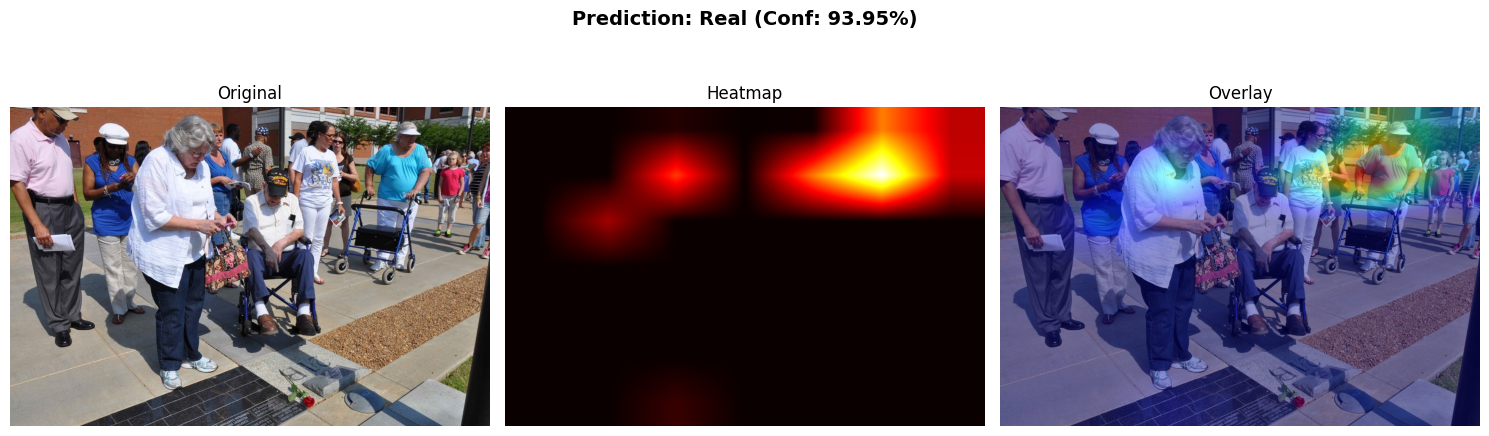


✓ Saved: /content/drive/MyDrive/skripsi/experiments/image_1e-4/visualizations/image_1e-4_example_real_heatmap.png

PREDICTION RESULTS
Input Sample   : Full-Synthetic
Predicted Class: Full-Synthetic
Confidence     : 99.19%

Class Probabilities:
  Real           : 0.0051 
  Full-Synthetic : 0.9919 ███████████████████████████████████████
  Tampered       : 0.0030 


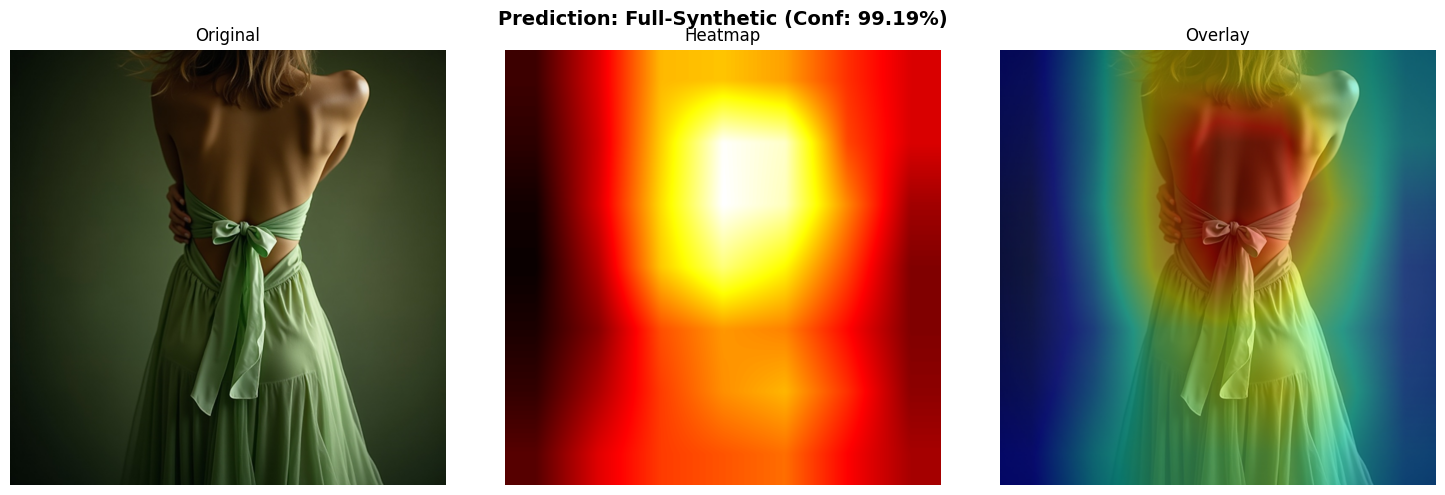


✓ Saved: /content/drive/MyDrive/skripsi/experiments/image_1e-4/visualizations/image_1e-4_example_full_synthetic_heatmap.png

PREDICTION RESULTS
Input Sample   : Tampered
Predicted Class: Tampered
Confidence     : 99.18%

Class Probabilities:
  Real           : 0.0029 
  Full-Synthetic : 0.0053 
  Tampered       : 0.9918 ███████████████████████████████████████


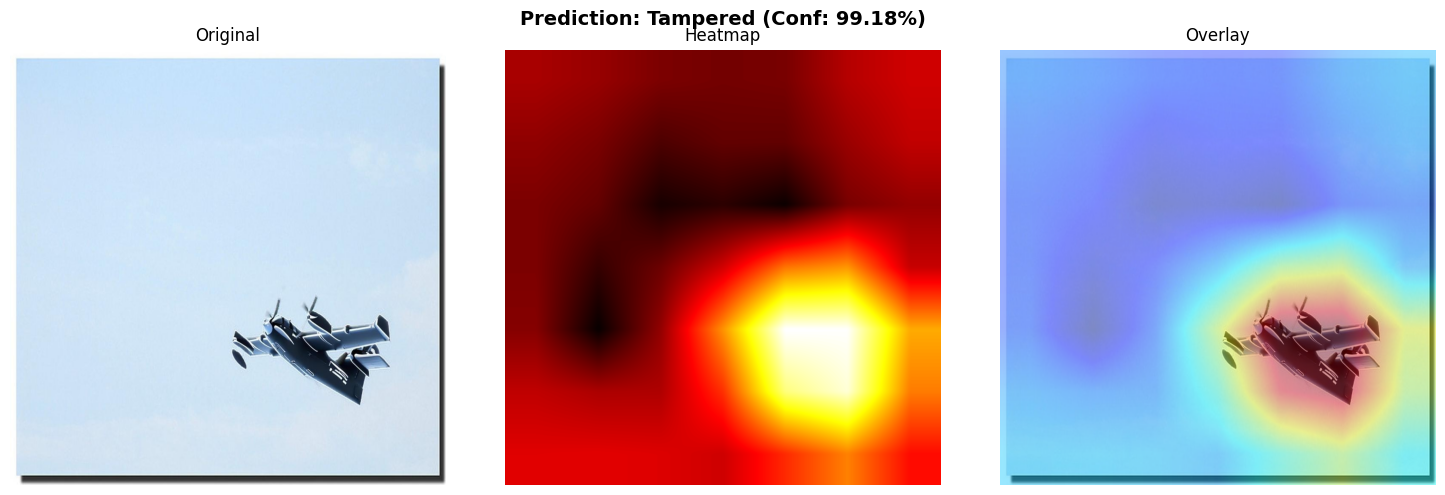


✓ Saved: /content/drive/MyDrive/skripsi/experiments/image_1e-4/visualizations/image_1e-4_example_tampered_heatmap.png


In [ ]:
# ======================== UPLOAD FROM COLAB ========================
# from google.colab import files
# print("Upload your image (JPEG, PNG, etc.):")
# uploaded = files.upload()
# image_path = list(uploaded.keys())[0]

# ======================== RUN PREDICTION ========================

def first_class_image(class_name):
    """Return one sample image from a class."""
    class_folder_path = os.path.join(DATASET_DIR, IMAGE_CLASS_FOLDER[class_name])

    if not os.path.exists(class_folder_path):
        raise FileNotFoundError(f"Folder not found: {class_folder_path}")

    sample_image_names = [
        image_file_name for image_file_name in os.listdir(class_folder_path)
        if Path(image_file_name).suffix.lower() in IMAGE_EXTENSIONS
    ]

    if len(sample_image_names) == 0:
        raise FileNotFoundError(f"No image found in: {class_folder_path}")

    return os.path.join(class_folder_path, sorted(sample_image_names)[0])


sample_paths = {
    class_name: first_class_image(class_name)
    for class_name in CLASS_NAMES
}

model = model.to(device)
model.eval()

detector = ImageDetector(
    image_model=model,
    device=device,
    image_transform=val_transform,
)

bar_width = 40

for class_name in CLASS_NAMES:
    res = detector.infer(sample_paths[class_name])

    print("\n" + "=" * 80)
    print("PREDICTION RESULTS")
    print("=" * 80)
    print(f"Input Sample   : {class_name}")
    print(f"Predicted Class: {res['label']}")
    print(f"Confidence     : {res['confidence']:.2%}")

    print("\nClass Probabilities:")
    for label in CLASS_NAMES:
        prob = res["probabilities"][label]
        bar = "█" * int(prob * bar_width)
        print(f"  {label:15s}: {prob:.4f} {bar}")

    display(res["visualization"])

    safe_name = class_name.replace(" ", "_").replace("-", "_").lower()
    heatmap_file_path = os.path.join(
        VIS_DIR,
        f"{experiment_name}_example_{safe_name}_heatmap.png"
    )

    res["visualization"].savefig(heatmap_file_path, dpi=150, bbox_inches="tight")
    print(f"\n✓ Saved: {heatmap_file_path}")

    plt.close(res["visualization"])

In [ ]:
# Zip the specific model file
!zip -j model.zip /content/models/images_best_model.pth

# Download the zip file
from google.colab import files
files.download("model.zip")

  adding: images_best_model.pth (deflated 7%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>